# Cancer Growth Dynamics: Treated MonoCulture Analysis
## IC25, IC50, IC75 Dose Response Modeling (20k Density)

**Fixed Drug Concentrations:**
- IC25: 1.47 µM (25% inhibition target) 
- IC50: 1.00 µM (50% inhibition reference)
- IC75: 0.62 µM (75% inhibition target)

**Cell Lines:** A2780 (naive) and A2780cis (cisplatin-resistant)

## Mathematical Model Description

### Core Model: Drug-Modified Logistic Growth

Your model combines **logistic growth** with **Hill equation dose-response** to describe cancer cell growth under drug treatment:

**Differential Equation:**
```
dN/dt = r_eff × N × (1 - N/K_eff)
```

Where:
- **N(t)** = Number of cells at time t
- **r_eff** = Effective growth rate (drug-modified)
- **K_eff** = Effective carrying capacity (drug-modified)

### Drug Effects via Hill Equation

The drug modifies both growth parameters through Hill dose-response relationships:

**Hill Function:**
```
inhibition = dose^n / (IC50^n + dose^n)
```

### Hierarchical Model Fitting Strategy

The analysis tries **5 model variants** in order of complexity until one succeeds:

**Model 2: Single Hill (3 parameters)**
- **n** = Single Hill coefficient for both effects
- **α_r** = Maximum growth rate inhibition
- **α_K** = Maximum carrying capacity inhibition


### Optimization Strategy

**Local Optimization:**
- Multiple optimizers: BFGS, LBFGS, NelderMead
- Multiple starting points for each optimizer
- Best result selected across all attempts

**Global Optimization:**
- Grid search for simpler models (≤3 parameters)
- Used as backup when local optimization fails

### Fixed Parameters

**From untreated controls:**
- **r** = Intrinsic growth rate
- **K** = Carrying capacity  
- **IC50** = 1.0 µM (reference concentration, fixed)

### Experimental Design

**Dose Conditions:**
- **IC25**: 1.47 µM (25% inhibition target)
- **IC50**: 1.00 µM (50% inhibition reference) 
- **IC75**: 0.62 µM (75% inhibition target)

**Cell Lines:**
- **A2780 (naive)** - Cisplatin-sensitive
- **A2780cis** - Cisplatin-resistant

**Total Analysis:** 6 conditions (3 doses × 2 cell lines), each fitted with best available model

## 1) Packages and Imports

In [1]:
# Install required packages if not already installed
using Pkg
Pkg.add(["CSV", "DataFrames", "StaticArrays", "Statistics", "DifferentialEquations", "Optim", "Plots", "LinearAlgebra", "ForwardDiff"])

# Load required packages
using CSV, DataFrames, Statistics
using DifferentialEquations, Optim, Plots
using LinearAlgebra, Printf
using Base.Threads
using ForwardDiff, StaticArrays

# Performance settings
BLAS.set_num_threads(min(4, Threads.nthreads()))
gr(fmt=:png, dpi=150)

println("✅ Essential packages loaded:")
println("  • Data: CSV, DataFrames, Statistics") 
println("  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff")
println("  • Visualization: Plots (GR backend)")
println("  • Performance: Base.Threads ($(Threads.nthreads()) threads), BLAS ($(BLAS.get_num_threads()) threads)")
println("  • Utilities: Printf")
println("✅ Setup completed - ready for analysis!")

   Resolving package versions...
  No Changes to `C:\Users\elbak\.julia\environments\v1.10\Project.toml`
  No Changes to `C:\Users\elbak\.julia\environments\v1.10\Manifest.toml`
Precompiling packages...
   6719.6 ms  ✓ Adapt → AdaptStaticArraysExt
   6560.5 ms  ✓ DifferentiationInterface → DifferentiationInterfaceStaticArraysExt
   6549.7 ms  ✓ ConstructionBase → ConstructionBaseStaticArraysExt
   6533.9 ms  ✓ ResettableStacks
   7558.0 ms  ✓ ArnoldiMethod
   2172.8 ms  ✓ ForwardDiff → ForwardDiffStaticArraysExt
   3813.8 ms  ✓ LazyArrays → LazyArraysStaticArraysExt
   2159.6 ms  ✓ StaticArrayInterface → StaticArrayInterfaceStaticArraysExt
   5869.2 ms  ✓ FastGaussQuadrature
   2016.6 ms  ✓ StructArrays → StructArraysStaticArraysExt
   2194.7 ms  ✓ Accessors → StaticArraysExt
   2471.1 ms  ✓ FiniteDiff → FiniteDiffStaticArraysExt
   6002.7 ms  ✓ ExponentialUtilities → ExponentialUtilitiesStaticArraysExt
   9512.2 ms  ✓ KernelAbstractions
   9516.3 ms  ✓ OrdinaryDiffEqStabilizedRK
   98

✅ Essential packages loaded:
  • Data: CSV, DataFrames, Statistics
  • Math: DifferentialEquations, Optim, LinearAlgebra, ForwardDiff
  • Visualization: Plots (GR backend)
  • Performance: Base.Threads (1 threads), BLAS (1 threads)
  • Utilities: Printf
✅ Setup completed - ready for analysis!


## 2) Paths and Data Directories

In [2]:
# Set up paths for IC25, IC50, IC75 data
# Since we're in a notebook, we need to construct the ROOT path from current working directory
ROOT = dirname(dirname(pwd()))

# Data directories for each dose
IC25_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC25", "Averages")
IC50_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")  
IC75_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC75", "Averages")

# Output directory
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "Multi_Dose_Analysis")
isdir(OUT_DIR) || mkpath(OUT_DIR)

# Baseline parameters file
RK_FILE = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_monoculture_logistic_parameters.csv")

println("📁 Data paths configured:")
println("  IC25 (1.47µM): $(isdir(IC25_DIR) ? "✅" : "❌") $IC25_DIR")
println("  IC50 (1.00µM): $(isdir(IC50_DIR) ? "✅" : "❌") $IC50_DIR")
println("  IC75 (0.62µM): $(isdir(IC75_DIR) ? "✅" : "❌") $IC75_DIR")
println("  Output: $OUT_DIR")
println("  Parameters: $(isfile(RK_FILE) ? "✅" : "❌") $RK_FILE")

using CSV, DataFrames

function load_day_averages_with_day0(path::AbstractString)
    @assert isfile(path) "Missing file: $path"
    df = CSV.read(path, DataFrame)

    # Exact column names from your processed data
    day_col    = findfirst(n -> String(n) == "Day",        names(df))
    mean_col   = findfirst(n -> String(n) == "Mean Cells", names(df))
    stderr_col = findfirst(n -> String(n) == "SEM Cells",  names(df))

    @assert day_col !== nothing && mean_col !== nothing "Could not find required columns in $path. Available: $(names(df))"

    x    = Float64.(df[!, day_col])
    y    = Float64.(df[!, mean_col])
    yerr = stderr_col !== nothing ? Float64.(df[!, stderr_col]) : zeros(length(y))

    # Sort
    p = sortperm(x); x, y, yerr = x[p], y[p], yerr[p]

    # Insert day 0 (67 for 20k, 100 for 30k)
    if minimum(x) > 0.1
        dens = occursin("20k", path) ? "20k" : (occursin("30k", path) ? "30k" : "20k")
        day0_cells = dens == "20k" ? 67.0 : 100.0
        x    = vcat([0.0], x)
        y    = vcat([day0_cells], y)
        yerr = vcat([max(day0_cells * 0.1, 1.0)], yerr)  # floor std error
    end

    # Limit to 0–12 days
    mask = x .<= 12.0
    return x[mask], y[mask], yerr[mask]
end

📁 Data paths configured:
  IC25 (1.47µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages
  IC50 (1.00µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
  IC75 (0.62µM): ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC75\Averages
  Output: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis
  Parameters: ✅ c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Untreated MonoCulture\untreated_monoculture_logistic_parameters.csv


load_day_averages_with_day0 (generic function with 1 method)

## 3) Utility Functions

In [3]:
function load_treated_timecourse(data_dir::AbstractString, cell_line::Symbol)
    cell_str = String(cell_line)  # e.g. "A2780cis"

    files = readdir(data_dir)

    # Prefer day_averages for this cell line
    matches = filter(f -> occursin(cell_str, f) && occursin("day_averages", f), files)

    if length(matches) == 0
        error("No *day_averages* file found for $(cell_line) in $(data_dir). Files: $(files)")
    elseif length(matches) > 1
        error("Multiple *day_averages* files match $(cell_line) in $(data_dir): $(matches)")
    end

    path = joinpath(data_dir, matches[1])
    return load_day_averages_with_day0(path)
end
function analyze_dose_set(
    dose_name::String,
    dose_value::Float64,
    data_dir::AbstractString,
    rk_params::Dict{Symbol,Tuple{Float64,Float64,Float64}};
    IC50_naive::Float64 = 1.0,
    IC50_cis::Float64   = 8.0,
    lambda_naive::Float64 = 0.5,
    lambda_cis::Float64   = 0.5,
)
    results = Dict{Symbol,Any}()
    cell_lines = [:A2780cis, :A2780Naive]

    println("🔬 Analyzing $dose_name ($dose_value µM)...")

    for cell_line in cell_lines
        println("  $cell_line: [fit] Dose=$dose_value")

        x, y, yerr = load_treated_timecourse(data_dir, cell_line)
        r, K, v    = rk_params[cell_line]

        if cell_line == :A2780cis
            IC50_fixed = IC50_cis
            λ_fixed    = lambda_cis
        else
            IC50_fixed = IC50_naive
            λ_fixed    = lambda_naive
        end

        res = fit_dose_response(
            x, y, yerr,
            r, K, v,
            dose_value;
            IC50_fixed = IC50_fixed,
            lambda     = λ_fixed,
            t_onset    = 0.0,
        )

        if res === nothing
            println("  ❌ $cell_line: fit failed ($(FIT_FAIL_REASON[]))")
            continue
        end

        println("  ✅ $cell_line: " *
                "Emax=$(round(res[:Emax], digits=2)), " *
                "n=$(round(res[:n], digits=2)), " *
                "λ=$(round(res[:lambda], digits=2)), " *
                "IC50=$(round(res[:IC50], digits=3)), " *
                "inhibition=$(round(100res[:inhibition], digits=1))%")

        results[cell_line] = res
    end

    return results
end



analyze_dose_set (generic function with 1 method)

## 4a) Hill function and dose helpers

In [4]:
# ============================================
# 2) Hill function and dose helpers
# ============================================

# Standard Hill function: H ∈ (0,1)
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

"""
    calculate_dose_for_inhibition(H, IC50; n=1.0)

Given target inhibition H in (0,1), IC50, and Hill coefficient n > 0,
solve H = dose^n / (IC50^n + dose^n) for dose:

    dose = IC50 * (H / (1 - H))^(1/n)
"""
function calculate_dose_for_inhibition(H, IC50; n::Float64 = 1.0)
    if H <= 0.0 || H >= 1.0 || IC50 <= 0.0 || n <= 0.0
        return NaN
    end
    return IC50 * (H / (1 - H))^(1 / n)
end

function calculate_dose_range(target_inhibitions, IC50; n::Float64 = 1.0)
    return [calculate_dose_for_inhibition(H, IC50; n=n) for H in target_inhibitions]
end

println("✅ Hill utilities loaded")
println("  • hill(dose, IC50, n)")
println("  • calculate_dose_for_inhibition / calculate_dose_range")

# ============================================
# 3) Theta-logistic × (1 - death_term) model
# ============================================

# Model:
#   growth = r P (1 - (P/K)^v)
#   death_term = Emax * H(dose(t)),  0 ≤ Emax ≤ 1
#   dP/dt = growth * (1 - death_term)
#
# Parameters:
#   r     : intrinsic growth rate (day⁻¹)
#   K     : carrying capacity (cells)
#   v     : crowding exponent (theta)
#   Emax  : maximal fractional inhibition (dimensionless, 0–1)
#   IC50  : half-max concentration
#   n     : Hill coefficient
#
# dose_fun(t) encodes the dosing schedule (constant or time-varying).

function treated_theta_logistic_mult!(du, u, p, t, dose_fun)
    r, K, v, Emax, IC50, n = p
    P = u[1]

    dose = dose_fun(t)
    H = hill(dose, IC50, n)              # ∈ (0,1)
    death_term = Emax * H                # ∈ (0,Emax)

    # Clamp to avoid negative factor numerically
    death_term = min(max(death_term, 0.0), 0.999)

    growth = r * P * (1 - (P / K)^v)
    du[1] = growth * (1 - death_term)
end

"""
    solve_treated_theta_logistic_mult(x, r, K, v;
                                      Emax=0.5,
                                      IC50=1.0,
                                      n=1.0,
                                      dose=1.0,
                                      y0=nothing,
                                      dose_fun=nothing)

Solve the theta-logistic model with multiplicative Hill inhibition:

    dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose(t)))

If `dose_fun` is not provided, uses a constant dose.
If `y0` is not provided, uses K * (0.018 / 0.95) as seeding (calculated by hand).

Returns: `sol` with `sol.t == x`.
"""
function solve_treated_theta_logistic_mult(
    x,
    r::Float64,
    K::Float64,
    v::Float64;
    Emax::Float64 = 0.5,
    IC50::Float64 = 1.0,
    n::Float64    = 1.0,
    dose::Float64 = 1.0,
    y0::Union{Nothing,Float64} = nothing,
    dose_fun::Union{Nothing,Function} = nothing,
)
    x = collect(Float64.(x))

    # initial condition
    if y0 === nothing
        # seeding rule from your plate setup (calculated by hand)
        y0 = K * (0.018 / 0.95)
    end

    # time span
    t0    = minimum(x)
    t_end = maximum(x)
    tspan = (t0, t_end)

    # dosing schedule
    local_dose_fun = dose_fun === nothing ? (t -> dose) : dose_fun

    # parameter vector: (r, K, v, Emax, IC50, n)
    p = [r, K, v, Emax, IC50, n]

    f = (du, u, p, t) -> treated_theta_logistic_mult!(du, u, p, t, local_dose_fun)
    prob = ODEProblem(f, [y0], tspan, p)

    sol = solve(prob, Tsit5();
                saveat = x,
                reltol = 1e-6,
                abstol = 1e-8,
                maxiters = 1000)

    return sol
end

println("✅ Theta-logistic × (1 - death_term) model loaded")
println("  • dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose))")
println("  • Emax is max fractional inhibition (0–1)")
println("  • Supports constant or time-varying dose_fun(t)")


✅ Hill utilities loaded
  • hill(dose, IC50, n)
  • calculate_dose_for_inhibition / calculate_dose_range
✅ Theta-logistic × (1 - death_term) model loaded
  • dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose))
  • Emax is max fractional inhibition (0–1)
  • Supports constant or time-varying dose_fun(t)


## 4b) Time dependent hill

In [5]:
# Time-ramp: starts at 0 and approaches 1
# lambda ≥ 0 controls how fast the drug effect turns on
ramp_factor(t, lambda::Float64, t_onset::Float64) = begin
    τ = t - t_onset
    if τ <= 0.0
        return 0.0
    else
        return 1.0 - exp(-lambda * τ)   # in (0,1)
    end
end

function treated_theta_logistic_mult_ramped!(du, u, p, t, dose_fun, lambda::Float64, t_onset::Float64)
    r, K, v, Emax, IC50, n = p
    P = u[1]

    dose = dose_fun(t)
    H = hill(dose, IC50, n)                # ∈ (0,1)
    base_death = Emax * H                  # ∈ (0,Emax)

    # Time ramp 0 → 1
    rf = ramp_factor(t, lambda, t_onset)   # ∈ [0,1)
    death_term = base_death * rf

    # Clamp to avoid numerical negatives
    death_term = min(max(death_term, 0.0), 0.999)

    growth = r * P * (1 - (P / K)^v)
    du[1] = growth * (1 - death_term)
end

"""
    solve_treated_theta_logistic_mult_ramped(
        x, r, K, v;
        Emax=0.5,
        IC50=1.0,
        n=1.0,
        dose=1.0,
        y0=nothing,
        dose_fun=nothing,
        lambda::Float64 = 0.5,
        t_onset::Float64 = 0.0,
    )

Theta-logistic model with time-ramped Hill inhibition:

    dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose(t)) * ramp(t))

where

    ramp(t) = 0                     for t ≤ t_onset
            = 1 - exp(-lambda*(t-t_onset))  for t > t_onset

If `dose_fun` is not provided, uses a constant dose.

Returns: `sol` with `sol.t == x`.
"""
function solve_treated_theta_logistic_mult_ramped(
    x,
    r::Float64,
    K::Float64,
    v::Float64;
    Emax::Float64 = 0.5,
    IC50::Float64 = 1.0,
    n::Float64    = 1.0,
    dose::Float64 = 1.0,
    y0::Union{Nothing,Float64} = nothing,
    dose_fun::Union{Nothing,Function} = nothing,
    lambda::Float64 = 0.5,
    t_onset::Float64 = 0.0,
)
    x = collect(Float64.(x))

    # initial condition
    if y0 === nothing
        y0 = K * (0.018 / 0.95)   # your original seeding rule
    end

    t0    = minimum(x)
    t_end = maximum(x)
    tspan = (t0, t_end)

    local_dose_fun = dose_fun === nothing ? (t -> dose) : dose_fun

    # parameter vector: (r, K, v, Emax, IC50, n)
    p = [r, K, v, Emax, IC50, n]

    f = (du, u, p, t) -> treated_theta_logistic_mult_ramped!(du, u, p, t, local_dose_fun, lambda, t_onset)
    prob = ODEProblem(f, [y0], tspan, p)

    sol = solve(prob, Tsit5();
                saveat = x,
                reltol = 1e-6,
                abstol = 1e-8,
                maxiters = 1000)

    return sol
end

println("✅ Time-ramped theta-logistic model loaded")
println("  • dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose) * ramp(t))")
println("  • ramp(t) = 0 → 1 with rate lambda, onset t_onset")


✅ Time-ramped theta-logistic model loaded
  • dP/dt = r P (1 - (P/K)^v) * (1 - Emax * H(dose) * ramp(t))
  • ramp(t) = 0 → 1 with rate lambda, onset t_onset


## 5) Fitting Functions

In [6]:
using Optim

# Shared mutable reason string
if !isdefined(Main, :FIT_FAIL_REASON)
    const FIT_FAIL_REASON = Ref("")
else
    FIT_FAIL_REASON[] = ""
end

function fit_dose_response(
    x::AbstractVector,
    y::AbstractVector,
    yerr::AbstractVector,
    r::Float64,
    K::Float64,
    v::Float64,
    dose::Float64;
    IC50_fixed::Float64 = 1.0,           # fixed IC50
    lambda::Float64     = 0.5,           # starting guess for λ
    t_onset::Float64    = 0.0,           # fixed onset for ramp
)
    # Cast to Float64 vectors
    x    = collect(Float64.(x))
    y    = collect(Float64.(y))
    yerr = collect(Float64.(yerr))
    @assert length(x) == length(y) == length(yerr) "x, y, yerr must have same length"
    @assert dose > 0 "dose must be > 0"

    # Normalize by day-0
    y0         = max(y[1], 1e-12)
    y_norm     = y ./ y0
    yerr_norm  = yerr ./ y0
    eps_val    = 1e-12
    w          = 1.0 ./ (yerr_norm.^2 .+ eps_val)

    # Parameter bounds for Emax, n, λ
    E_lo, E_hi   = 0.1, 1.2
    n_lo, n_hi   = 0.5, 4.0
    λ_lo, λ_hi   = 0.05, 5.0   # adjust if you have a better prior range

    # Loss: SSE with light regularization
    function loss(params)
        Emax, n, λ = params
        IC50       = IC50_fixed

        local sol
        try
            sol = solve_treated_theta_logistic_mult_ramped(
                x, r, K, v;
                Emax   = Emax,
                IC50   = IC50,
                n      = n,
                dose   = dose,
                y0     = y[1],
                lambda = λ,
                t_onset = t_onset,
            )
        catch e
            FIT_FAIL_REASON[] = "loss exception: " * string(typeof(e))
            println("[fit] " * FIT_FAIL_REASON[])
            return 1e10
        end

        if sol.retcode != :Success
            FIT_FAIL_REASON[] = "ODE retcode=" * string(sol.retcode)
            println("[fit] " * FIT_FAIL_REASON[])
            return 1e9
        end

        pred = getindex.(sol.u, 1)
        if length(pred) != length(y)
            FIT_FAIL_REASON[] = "pred length mismatch"
            println("[fit] " * FIT_FAIL_REASON[])
            return 1e10
        end

        pred_norm = pred ./ y0

        resid = y_norm .- pred_norm
        sse   = sum(w .* resid.^2)

        # regularize all three parameters mildly
        reg = 1e-6 * (Emax^2 + n^2 + λ^2)

        return sse + reg
    end

    # Initial guesses
    final_reduction = max(0.0, 1.0 - y_norm[end])
    E0 = clamp(final_reduction,         E_lo, E_hi)
    n0 = clamp(dose / IC50_fixed,       n_lo, n_hi)
    λ0 = clamp(lambda,                  λ_lo, λ_hi)  # use keyword as starting λ

    initial = [E0, n0, λ0]

    lower   = [E_lo, n_lo, λ_lo]
    upper   = [E_hi, n_hi, λ_hi]

    println("[fit] Dose=$(dose), initial=$(initial)")

    method  = Fminbox(NelderMead())
    options = Optim.Options(
        iterations   = 500,
        g_abstol     = 1e-8,
        show_trace   = false,
        store_trace  = false,
    )

    result = Optim.optimize(loss, lower, upper, initial, method, options)

    println("[fit] Converged=$(Optim.converged(result)), min=$(Optim.minimum(result))")

    if !Optim.converged(result)
        FIT_FAIL_REASON[] = "optimizer did not converge"
        return nothing
    end

    E_opt, n_opt, λ_opt = Optim.minimizer(result)
    IC50_eff = IC50_fixed

    # Final treated simulation with optimal parameters
    sol_treated = try
        solve_treated_theta_logistic_mult_ramped(
            x, r, K, v;
            Emax   = E_opt,
            IC50   = IC50_eff,
            n      = n_opt,
            dose   = dose,
            y0     = y[1],
            lambda = λ_opt,
            t_onset = t_onset,
        )
    catch e
        FIT_FAIL_REASON[] = "final exception: " * string(typeof(e))
        println("[fit] " * FIT_FAIL_REASON[])
        return nothing
    end

    if sol_treated.retcode != :Success
        FIT_FAIL_REASON[] = "final ODE retcode=" * string(sol_treated.retcode)
        println("[fit] " * FIT_FAIL_REASON[])
        return nothing
    end

    y_pred = getindex.(sol_treated.u, 1)

    # Untreated baseline (Emax=0, dose=0) for inhibition
    sol_untreated = solve_treated_theta_logistic_mult(
        x, r, K, v;
        Emax = 0.0,
        IC50 = IC50_eff,  # irrelevant when dose=0
        n    = 1.0,
        dose = 0.0,
        y0   = y[1],
    )

    if sol_untreated.retcode != :Success
        FIT_FAIL_REASON[] = "baseline ODE retcode=" * string(sol_untreated.retcode)
        println("[fit] " * FIT_FAIL_REASON[])
        return nothing
    end

    y_untreated = getindex.(sol_untreated.u, 1)

    # Inhibition at final time
    inh = 1.0 - y_pred[end]/y_untreated[end]

    return (
        x = x, y = y, yerr = yerr,
        y_pred = y_pred,
        r = r, K = K, v = v,
        dose = dose,
        IC50 = IC50_eff,
        Emax = E_opt, n = n_opt,
        lambda = λ_opt,
        inhibition = inh,
        ssr = Optim.minimum(result),
        converged = true,
        sol_treated = sol_treated,
        sol_untreated = sol_untreated,
    )
end



fit_dose_response (generic function with 1 method)

## 6) Load Baseline Parameters and Raw Data

In [7]:
using CSV, DataFrames

"""
    load_baseline_parameters(file::AbstractString)

Load baseline theta-logistic parameters (r, K, v) from a CSV file with columns:
File, Density, CellLine, r, K, v, SSR, BIC.

Returns a Dict mapping cell line Symbols → (r, K, v).
If duplicates (e.g. 20k vs. 30k) exist, keeps the row with smaller BIC.
"""
function load_baseline_parameters(file::AbstractString)
    @assert isfile(file) "Missing baseline file: $file"

    df = CSV.read(file, DataFrame)

    required = [:CellLine, :r, :K, :v, :BIC]
    missing_cols = setdiff(required, Symbol.(names(df)))
    @assert isempty(missing_cols) "Missing columns: $(missing_cols)"

    # group by CellLine and keep best (lowest BIC)
    grouped = groupby(df, :CellLine)
    best_rows = combine(grouped) do sub
        sub[argmin(sub.BIC), :]
    end

    params = Dict{Symbol, Tuple{Float64, Float64, Float64}}()
    for row in eachrow(best_rows)
        cell = Symbol(row.CellLine)
        params[cell] = (Float64(row.r), Float64(row.K), Float64(row.v))
    end

    return params
end
println("📊 Loading baseline parameters...")
rk_params = load_baseline_parameters(RK_FILE)

println("✅ Baseline parameters loaded:")
for (cell_line, (r, K, v)) in rk_params
    println("  $(String(cell_line)): r=$(round(r, digits=4)), K=$(round(K, digits=1)), v=$(round(v, digits=3))")
end

dose_conditions = [
    ("IC25", 1.47, IC25_DIR),
    ("IC50", 1.00, IC50_DIR),
    ("IC75", 0.62, IC75_DIR),
]


📊 Loading baseline parameters...
✅ Baseline parameters loaded:
  A2780cis: r=0.464, K=3793.4, v=3.547
  A2780Naive: r=1.1367, K=4077.2, v=0.624


3-element Vector{Tuple{String, Float64, String}}:
 ("IC25", 1.47, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC25\\Averages")
 ("IC50", 1.0, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC50\\Averages")
 ("IC75", 0.62, "c:\\Users\\elbak\\OneDrive\\Desktop\\ForgeFit\\CancerGrowthDynamics\\Processed_Datasets\\Treated MonoCulture\\20k\\IC75\\Averages")

## 7) Running Function

In [8]:
dose_conditions = [
    ("IC25", 1.47, IC25_DIR),
    ("IC50", 1.00, IC50_DIR),
    ("IC75", 0.62, IC75_DIR),
]

rk_params = load_baseline_parameters(RK_FILE)  # Dict{Symbol,(r,K,v)}

all_results = Dict{String,Dict{Symbol,Any}}()

for (dose_name, dose_value, data_dir) in dose_conditions
    println()
    println("============== $dose_name ==============")

    dose_results = analyze_dose_set(
        dose_name,
        dose_value,
        data_dir,
        rk_params;
        IC50_naive = 1.0,
        IC50_cis   = 8.0,
        lambda_naive = 0.5,   # change if you want
        lambda_cis   = 0.5,
    )

    all_results[dose_name] = dose_results
end

println("\n✅ Dose–response modeling complete.")



============== IC25 ==============
🔬 Analyzing IC25 (1.47 µM)...
  A2780cis: [fit] Dose=1.47
[fit] Dose=1.47, initial=[0.1, 0.5, 0.5]


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1, 2]
└ @ Optim C:\Users\elbak\.julia\packages\Optim\8dE7C\src\multivariate\solvers\constrained\fminbox.jl:441


[fit] Converged=true, min=1540.8266028774274
  ✅ A2780cis: Emax=1.2, n=0.5, λ=0.14, IC50=8.0, inhibition=4.0%
  A2780Naive: [fit] Dose=1.47
[fit] Dose=1.47, initial=[0.1, 1.47, 0.5]
[fit] Converged=true, min=278.6251581622964
  ✅ A2780Naive: Emax=1.2, n=3.99, λ=1.29, IC50=1.0, inhibition=95.8%

┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1]
└ @ Optim C:\Users\elbak\.julia\packages\Optim\8dE7C\src\multivariate\solvers\constrained\fminbox.jl:441




============== IC50 ==============
🔬 Analyzing IC50 (1.0 µM)...
  A2780cis: [fit] Dose=1.0
[fit] Dose=1.0, initial=[0.1, 0.5, 0.5]
[fit] Converged=true, min=1629.5590051583852
  ✅ A2780cis: Emax=0.13, n=3.88, λ=0.07, IC50=8.0, inhibition=0.0%
  A2780Naive: [fit] Dose=1.0
[fit] Dose=1.0, initial=[0.1, 1.0, 0.5]
[fit] Converged=true, min=996.1234646471155
  ✅ A2780Naive: Emax=1.2, n=2.5, λ=0.83, IC50=1.0, inhibition=28.8%

============== IC75 ==============
🔬 Analyzing IC75 (0.62 µM)...
  A2780cis: [fit] Dose=0.62
[fit] Dose=0.62, initial=[0.1, 0.5, 0.5]


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1, 2]
└ @ Optim C:\Users\elbak\.julia\packages\Optim\8dE7C\src\multivariate\solvers\constrained\fminbox.jl:441
┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1]
└ @ Optim C:\Users\elbak\.julia\packages\Optim\8dE7C\src\multivariate\solvers\constrained\fminbox.jl:441
┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1, 2]
└ @ Optim C:\Users\elbak\.julia\packages\Optim\8dE7C\src\multivariate\solvers\constrained\fminbox.jl:441


[fit] Converged=true, min=200.93017559877686
  ✅ A2780cis: Emax=0.71, n=1.59, λ=0.05, IC50=8.0, inhibition=0.0%
  A2780Naive: [fit] Dose=0.62
[fit] Dose=0.62, initial=[0.1, 0.62, 0.5]
[fit] Converged=true, min=111.88107841940516
  ✅ A2780Naive: Emax=1.2, n=0.5, λ=0.59, IC50=1.0, inhibition=15.6%

✅ Dose–response modeling complete.


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1]
└ @ Optim C:\Users\elbak\.julia\packages\Optim\8dE7C\src\multivariate\solvers\constrained\fminbox.jl:441


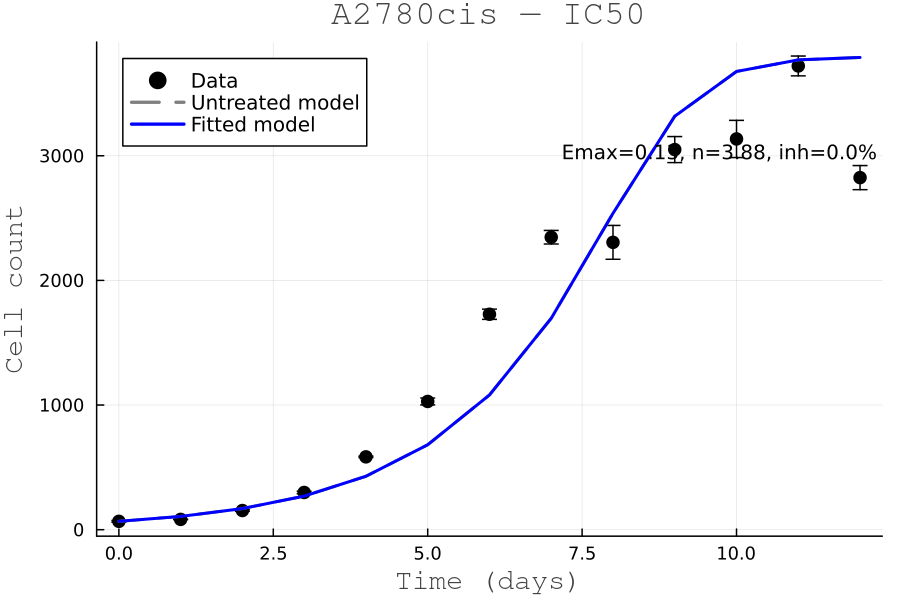

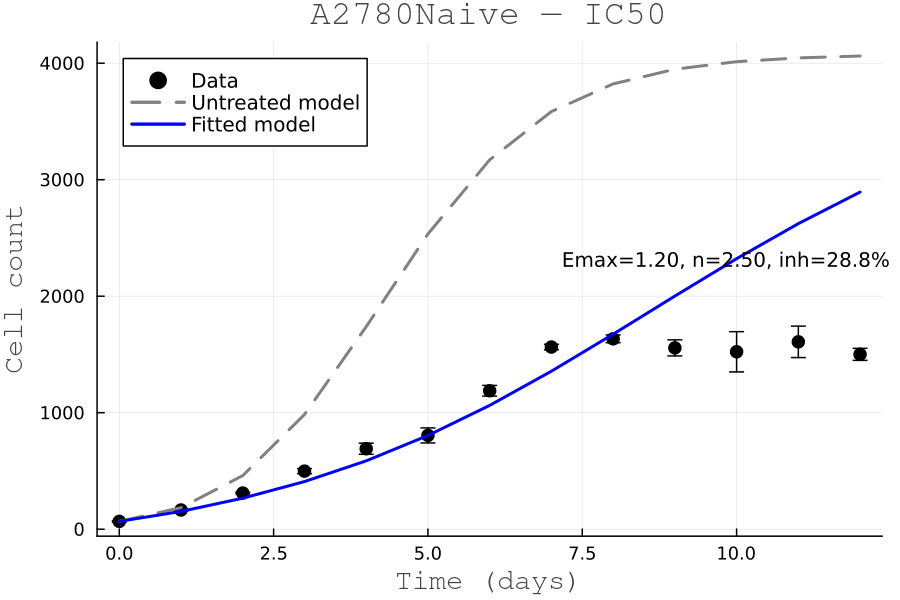

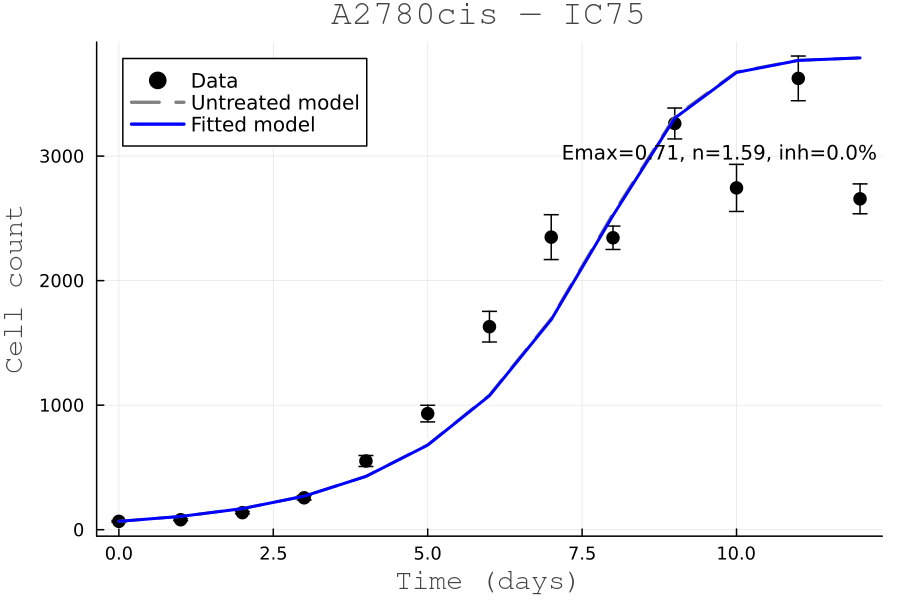

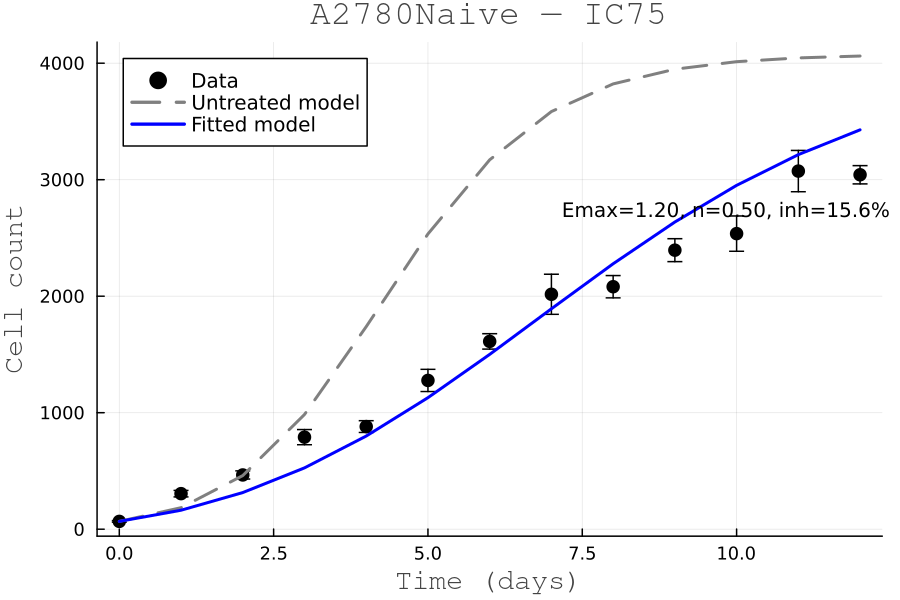

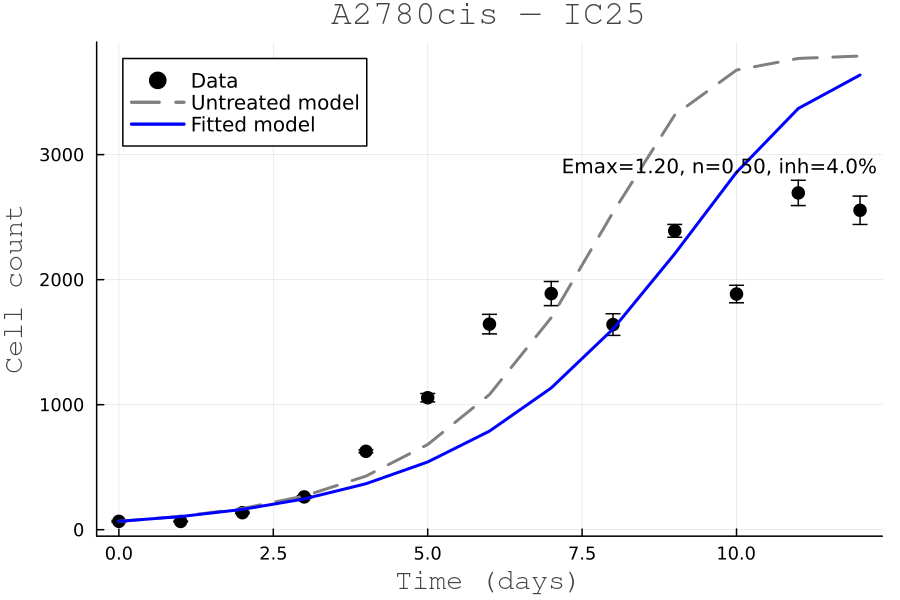

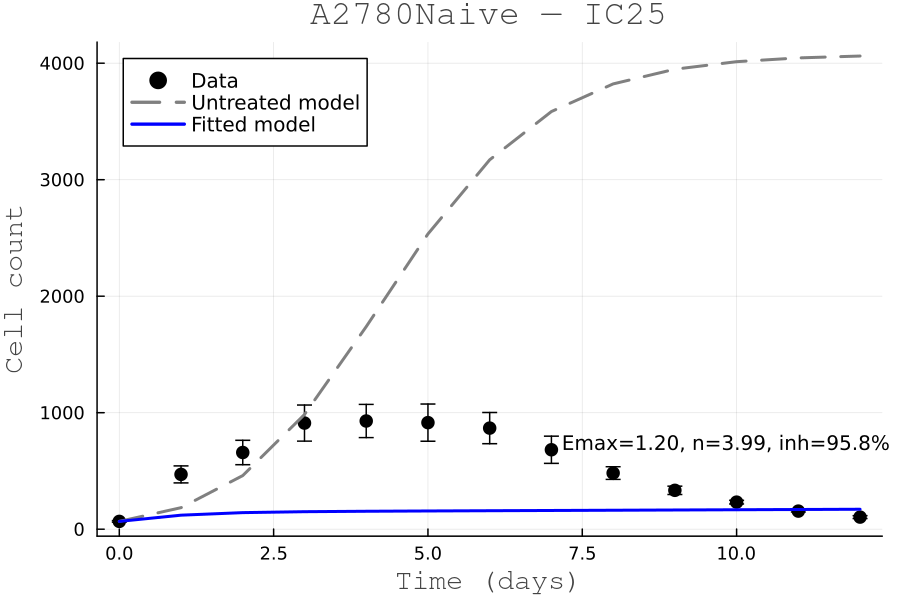

GKS: could not find font Arial.ttf


In [9]:
#Plot all the dose fits

"""
    plot_dose_fit(all_results, rk_params; save_dir=nothing)

Plot experimental data (points with error bars) and model predictions
for each dose and cell line. Optionally save figures into `save_dir`.
"""
function plot_dose_fit(all_results::Dict{String,Dict{Symbol,Any}},
                       rk_params::Dict{Symbol,Tuple{Float64,Float64,Float64}};
                       save_dir::Union{Nothing,String}=nothing)

    default(titlefont=font(12, "Arial"),
            guidefont=font(10, "Arial"),
            legendfontsize=9,
            lw=2, ms=5)

    for (dose_name, results) in all_results
        for (cell_line, fit) in results
            if fit === nothing
                @warn "No fit stored for $cell_line at $dose_name"
                continue
            end

            # Extract data
            x = fit.x
            y = fit.y
            yerr = fit.yerr
            y_pred = fit.y_pred

            # untreated comparison (for context)
            sol_unt = fit.sol_untreated
            y_unt = getindex.(sol_unt.u, 1)
            x_unt = sol_unt.t

            # Build plot
            p = plot(title = "$(String(cell_line)) — $(dose_name)",
                     xlabel = "Time (days)",
                     ylabel = "Cell count",
                     legend = :topleft)

            # Experimental data
            scatter!(p, x, y; yerror=yerr, label="Data", color=:black, marker=:circle)

            # Untreated model (baseline)
            plot!(p, x_unt, y_unt; label="Untreated model", color=:gray, ls=:dash)

            # Treated model prediction
            plot!(p, x, y_pred; label="Fitted model", color=:blue)

            # Text info
            ann = @sprintf "Emax=%.2f, n=%.2f, inh=%.1f%%" fit.Emax fit.n fit.inhibition*100
            annotate!(p, (x[end]*0.6, maximum(vcat(y, y_pred))*0.8, text(ann, 9, :left)))

            display(p)

            # Optionally save
            if save_dir !== nothing
                isdir(save_dir) || mkpath(save_dir)
                file_name = joinpath(save_dir, "$(String(cell_line))_$(dose_name)_fit.png")
                savefig(p, file_name)
            end
        end
    end
end

# Example usage:
plot_dose_fit(all_results, rk_params; save_dir=OUT_DIR)


In [10]:
cell_color(name::AbstractString) = occursin("cis", lowercase(name)) ? :orange : :steelblue

function list_csvs(dir::AbstractString)
    if !isdir(dir)
    @warn "Directory not found: $dir"
    return String[]
    end
    files = filter(f -> endswith(lowercase(f), ".csv"), readdir(dir; join=true))
    return sort(files)
end

function safe_load_day_averages(path::AbstractString)
    if isdefined(Main, :load_day_averages_with_day0)
    return load_day_averages_with_day0(path)
    else
    df = CSV.read(path, DataFrame)
    day_col = findfirst(n -> String(n) == "Day", names(df))
    mean_col = findfirst(n -> String(n) == "Mean Cells", names(df))
    sem_col = findfirst(n -> String(n) == "SEM Cells", names(df))
    @assert day_col !== nothing && mean_col !== nothing "Columns Day/Mean Cells missing in $path"
    x = Float64.(df[!, day_col])
    y = Float64.(df[!, mean_col])
    yerr = sem_col === nothing ? nothing : Float64.(df[!, sem_col])
    perm = sortperm(x)
    x = x[perm]
    y = y[perm]
    yerr = yerr === nothing ? nothing : yerr[perm]
    return x, y, yerr
    end
end

function plot_all_treated_processed(IC25_DIR::AbstractString,
    IC50_DIR::AbstractString,
    IC75_DIR::AbstractString;
    ncols::Int=6,
    size::Tuple{Int,Int}=(2400, 1200),
    show_errors::Bool=true,
    save_path::Union{Nothing,String}=nothing)

    doses = [("IC25", IC25_DIR), ("IC50", IC50_DIR), ("IC75", IC75_DIR)]
    nrows = length(doses)

    per_row_files = Vector{Vector{String}}(undef, nrows)
    x_max = 0.0
    y_max = 0.0

    for i in 1:nrows
        dose_name, dir = doses[i]
        files = list_csvs(dir)
        per_row_files[i] = files
        for f in files
            try
                x, y, _ = safe_load_day_averages(f)
                if !isempty(x)
                    x_max = max(x_max, maximum(x))
                end
                if !isempty(y)
                    y_max = max(y_max, maximum(y))
                end
            catch e
                @warn "Failed reading $f: $e"
            end
        end
    end

    if y_max == 0.0
        y_max = 1.0
    end

    plt = plot(layout=(nrows, ncols), size=size, legend=false)
    plot_idx = (r, c) -> (r - 1) * ncols + c

    for row in 1:nrows
        dose_name, _ = doses[row]
        files = per_row_files[row]
        for col in 1:ncols
            sp = plot_idx(row, col)
            if col <= length(files)
                f = files[col]
                fn = basename(f)
                cell_line = split(fn, "_")[1]
                c = cell_color(cell_line)

                try
                    x, y, yerr = safe_load_day_averages(f)
                    xl = row == nrows ? "Day" : ""
                    yl = col == 1 ? "Mean Cells" : ""
                    ttl = "$dose_name • $cell_line"

                    if show_errors && yerr !== nothing
                        scatter!(plt, x, y; yerror=yerr, color=c, ms=3, alpha=0.9,
                                subplot=sp, label=false, title=ttl, xlabel=xl, ylabel=yl)
                    else
                        scatter!(plt, x, y; color=c, ms=3, alpha=0.9,
                                subplot=sp, label=false, title=ttl, xlabel=xl, ylabel=yl)
                    end

                    xlims!(plt, (0.0, x_max); subplot=sp)
                    ylims!(plt, (0.0, y_max * 1.1); subplot=sp)
                catch e
                    @warn "Plotting failed for $f: $e"
                    plot!(plt; subplot=sp, title="$dose_name • (failed: $cell_line)", xlabel="", ylabel="")
                    xlims!(plt, (0.0, x_max); subplot=sp)
                    ylims!(plt, (0.0, y_max * 1.1); subplot=sp)
                end
            else
                plot!(plt; subplot=sp, title="", xlabel="", ylabel="")
                xlims!(plt, (0.0, x_max); subplot=sp)
                ylims!(plt, (0.0, y_max * 1.1); subplot=sp)
            end
        end
    end

    display(plt)

    if save_path !== nothing
        try
            savefig(plt, save_path)
            println("✅ Saved figure to $save_path")
        catch e
            @warn "Could not save figure: $e"
        end
    end

    return plt
end

plot_all_treated_processed (generic function with 1 method)

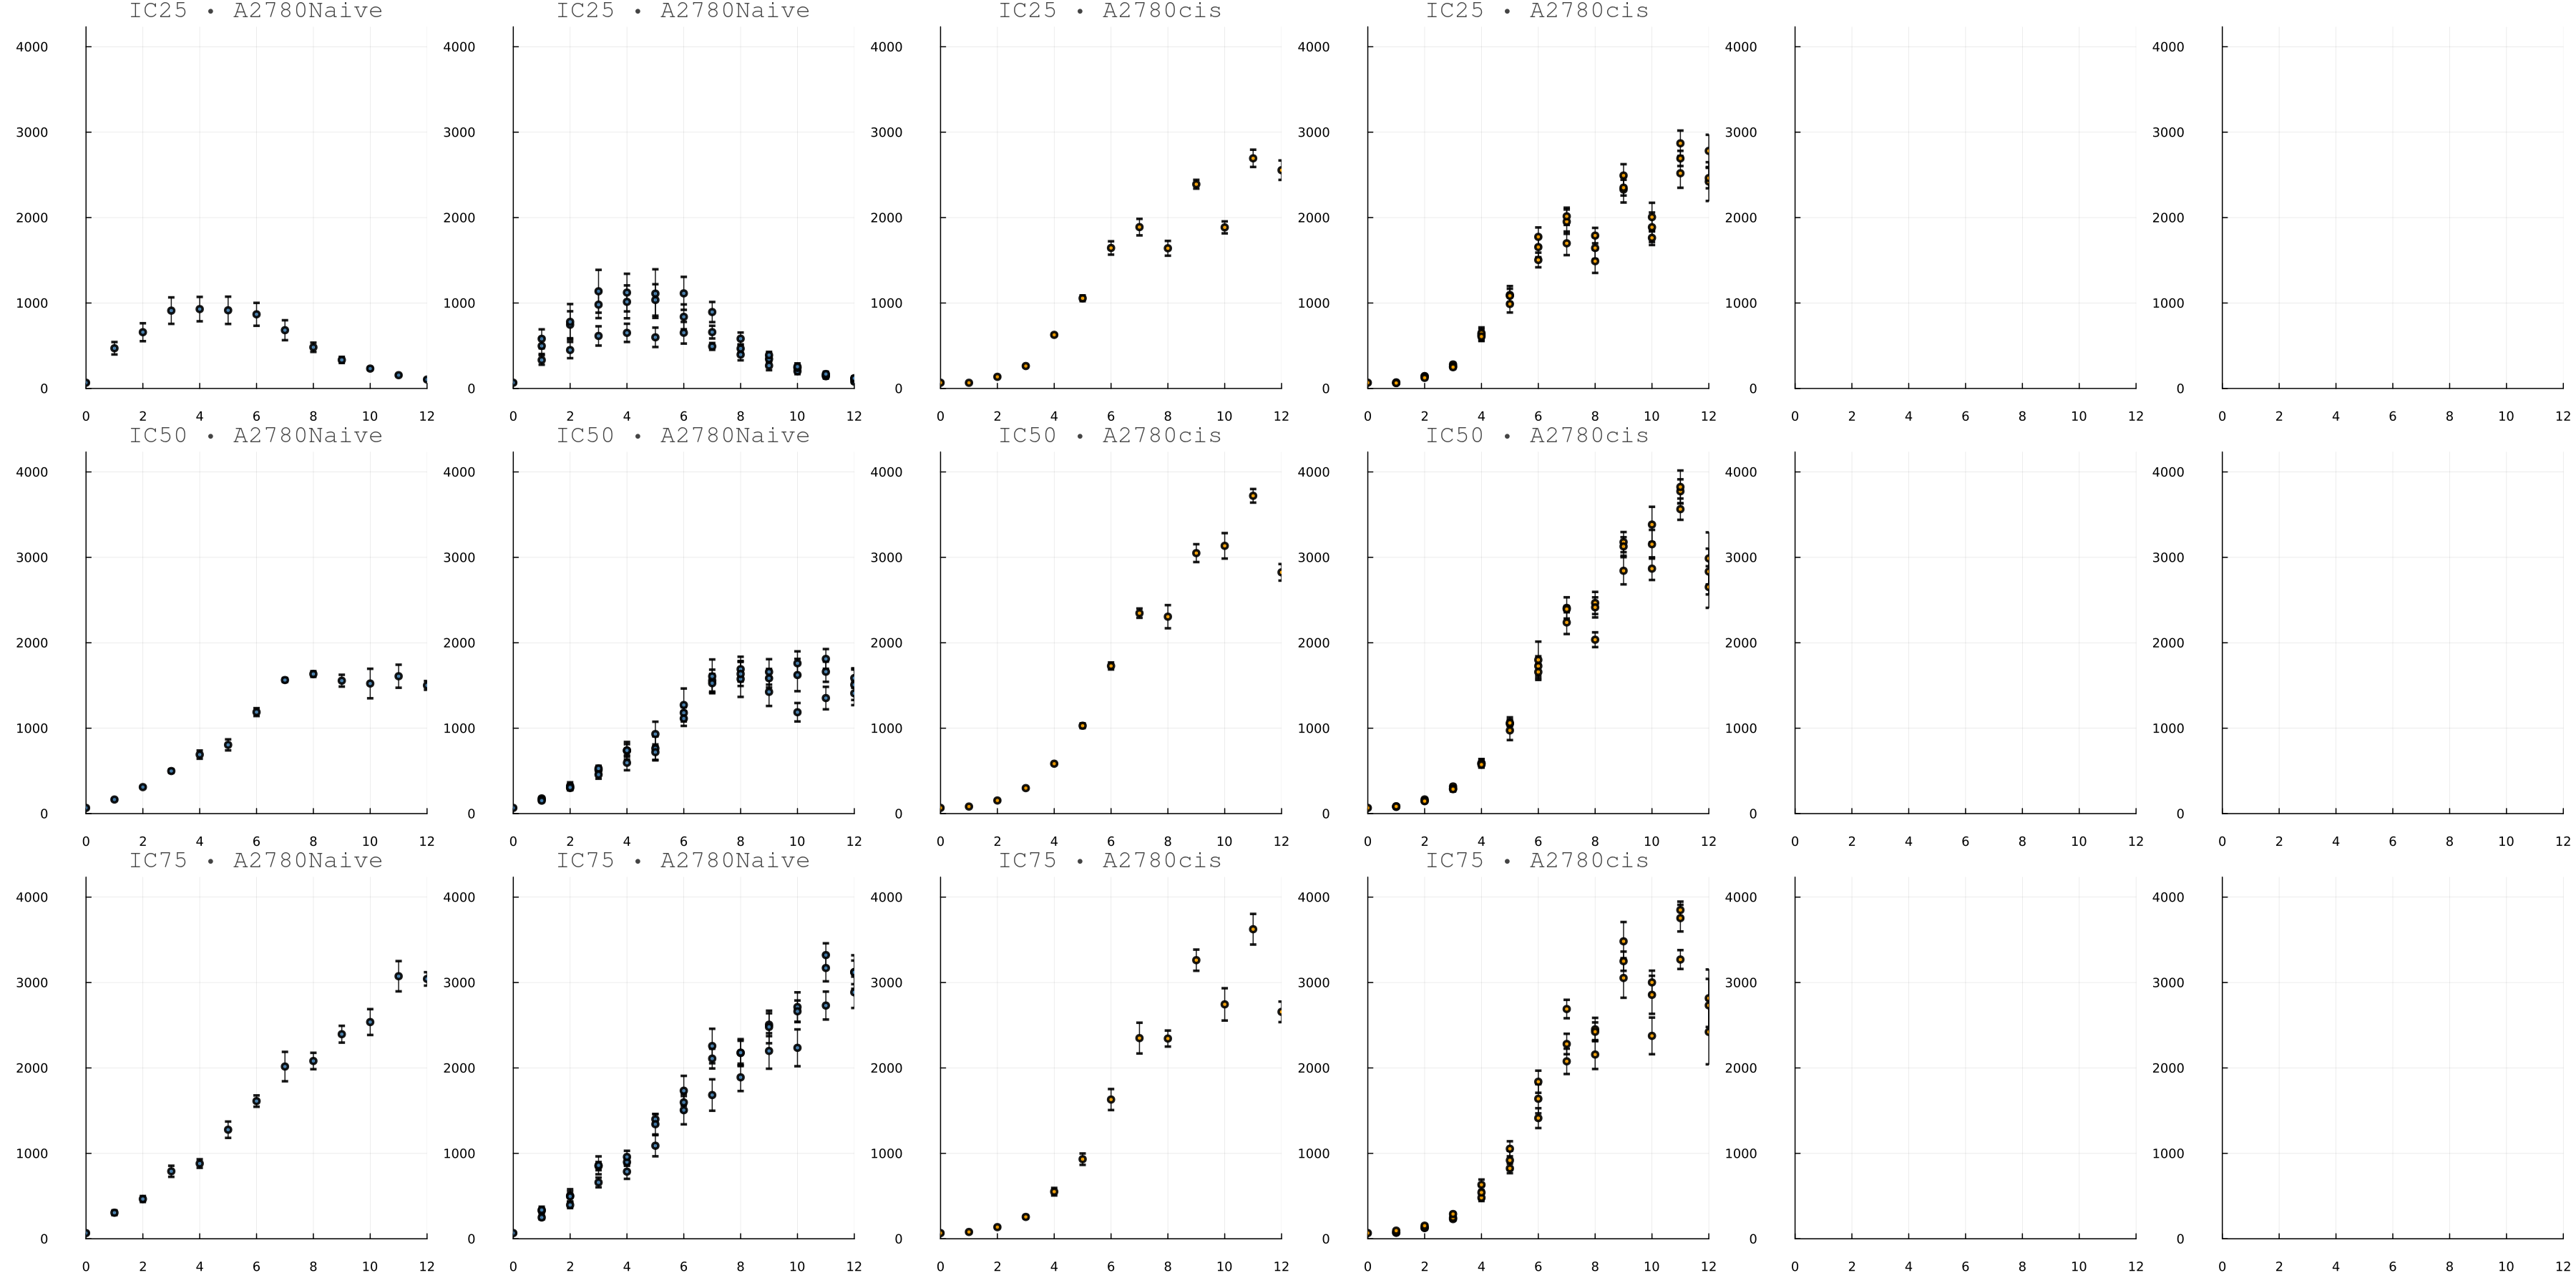

✅ Saved figure to c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis\treated_processed_3x6.png


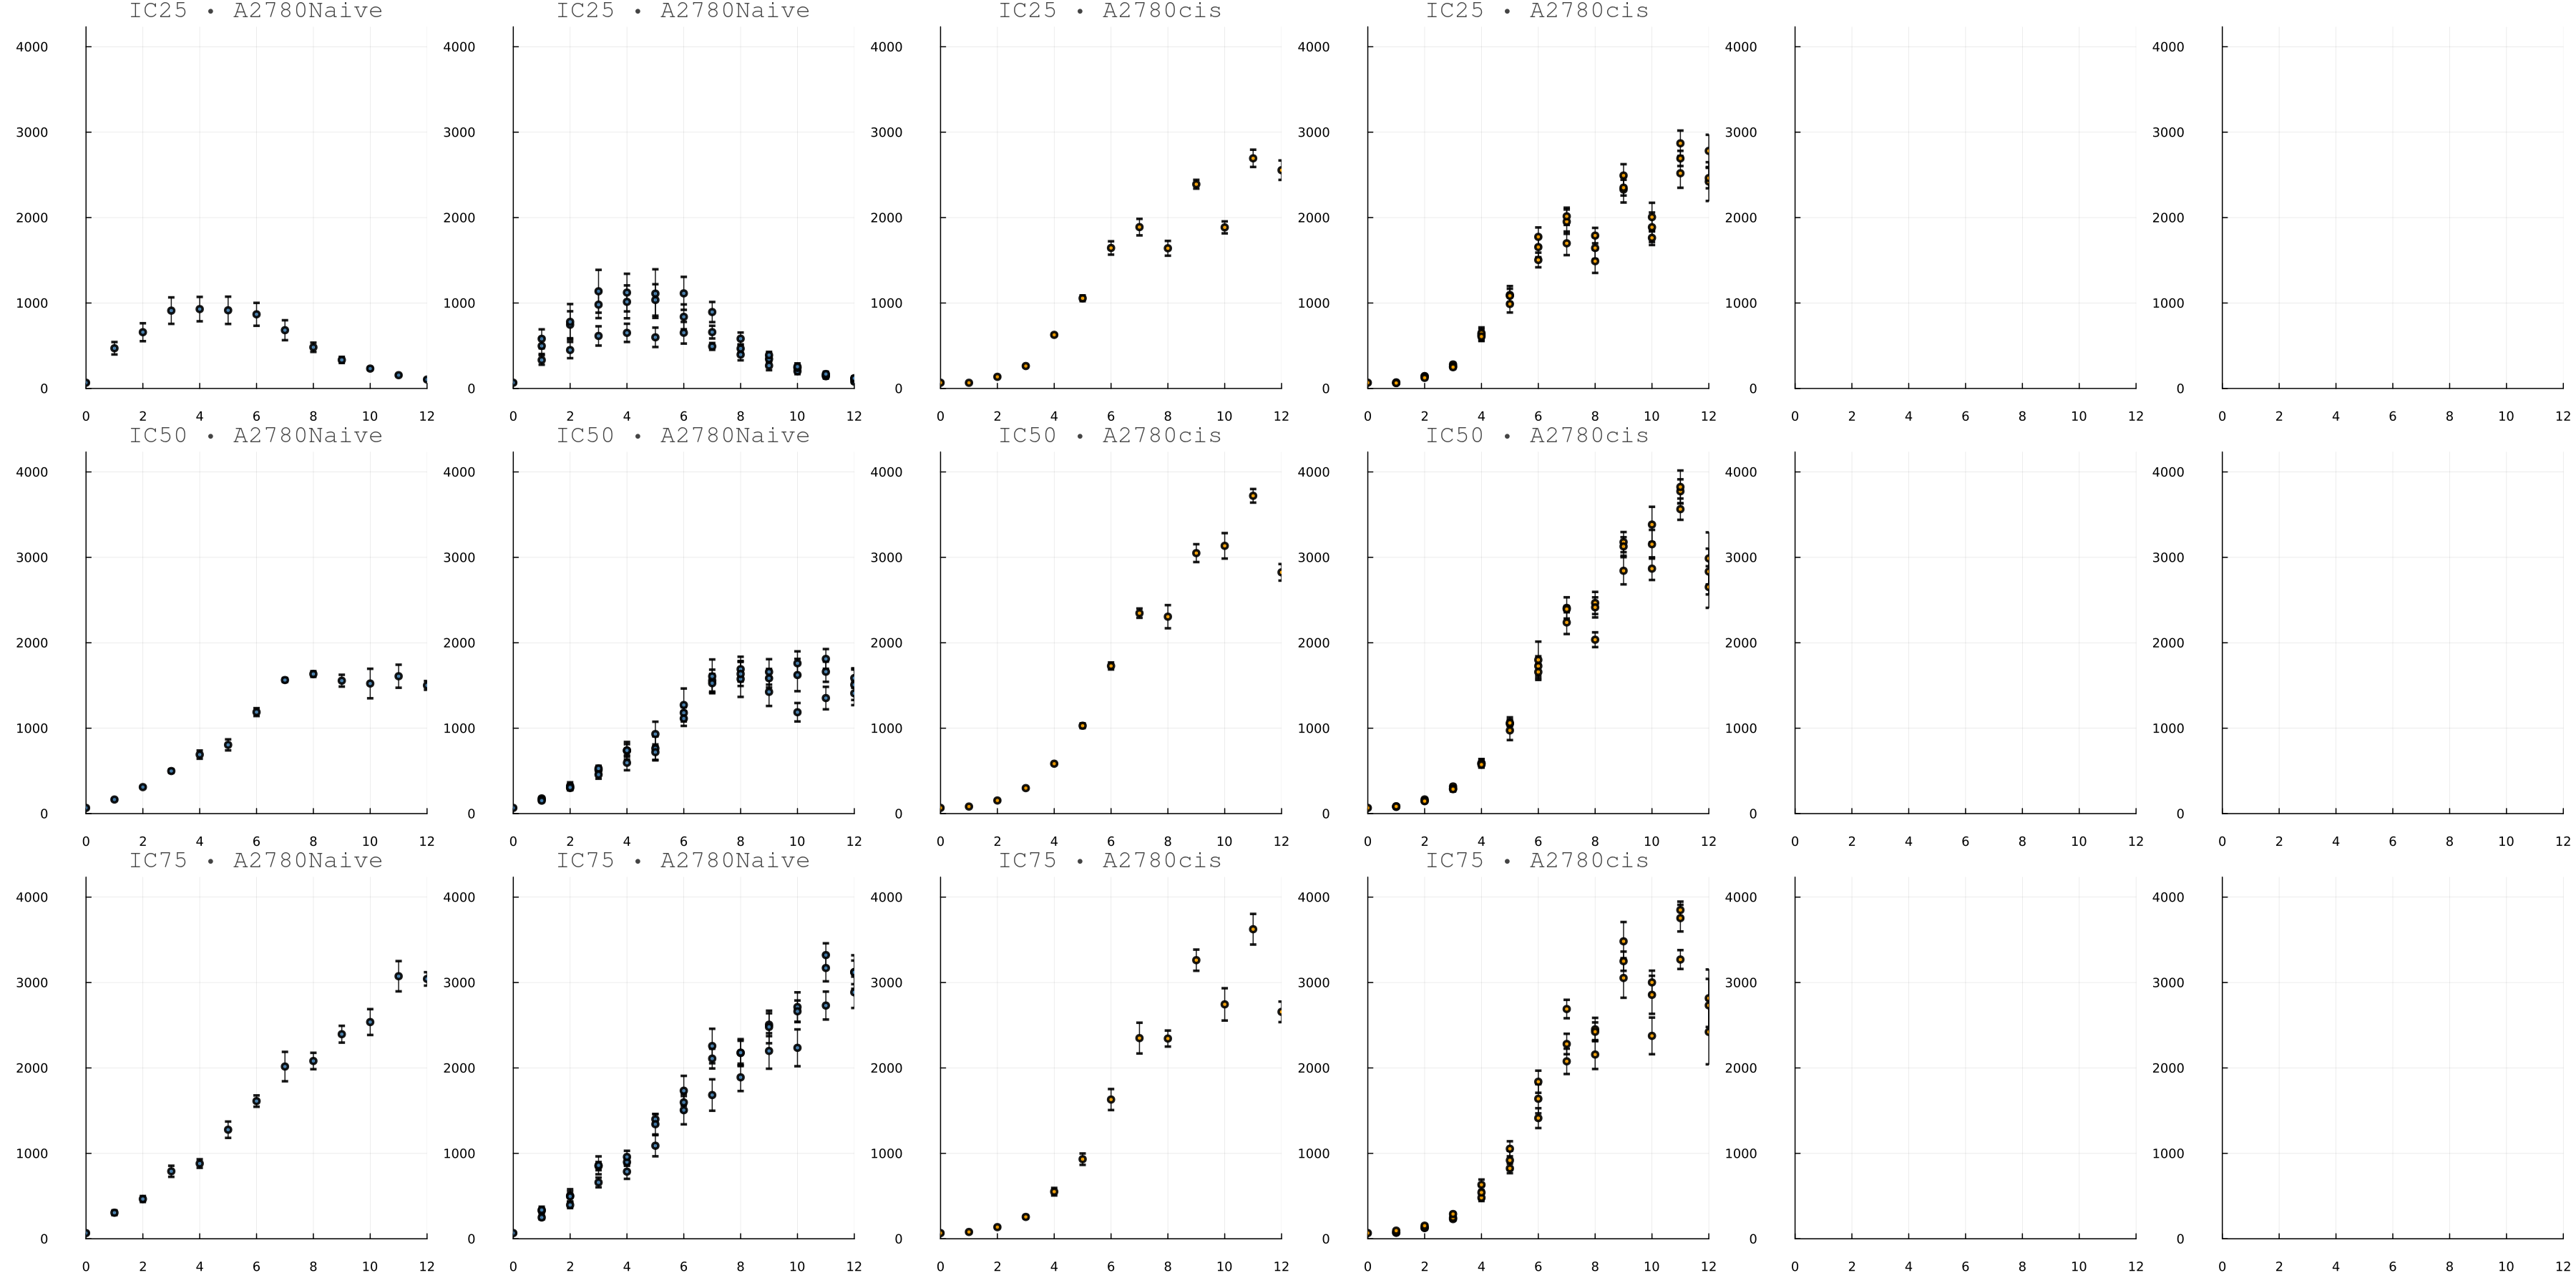

In [11]:
plot_all_treated_processed(IC25_DIR, IC50_DIR, IC75_DIR; ncols=6, save_path=joinpath(OUT_DIR, "treated_processed_3x6.png"))

## Multifit


Fitting A2780Naive at IC25 (20k treated)
Dataset: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC25\Averages\A2780Naive_day_averages.csv
Best model by BIC: Model2_parpi
Parameters: (alpha = 0.7413656082520879, beta = 0.0030273233053062843, d = 0.6353296536798947)
SSE = 123.96703781693193, BIC = 37.010710606121904, AIC = 35.31586253373729
Saved plot to c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\Multi_Dose_Analysis\model_comparison_A2780Naive_IC25_20k.png

Fitting A2780Naive at IC50 (20k treated)
Dataset: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780Naive_day_averages.csv
Best model by BIC: two_pop_static_res
Parameters: (f_sens0 = 0.7405326074358864, E_sens = 0.622120135030304, n = 0.7839767622485402, IC50 = 0.1057391043700767, lambda = 3.7113523203462506)
SSE = 69.38550715324587, B

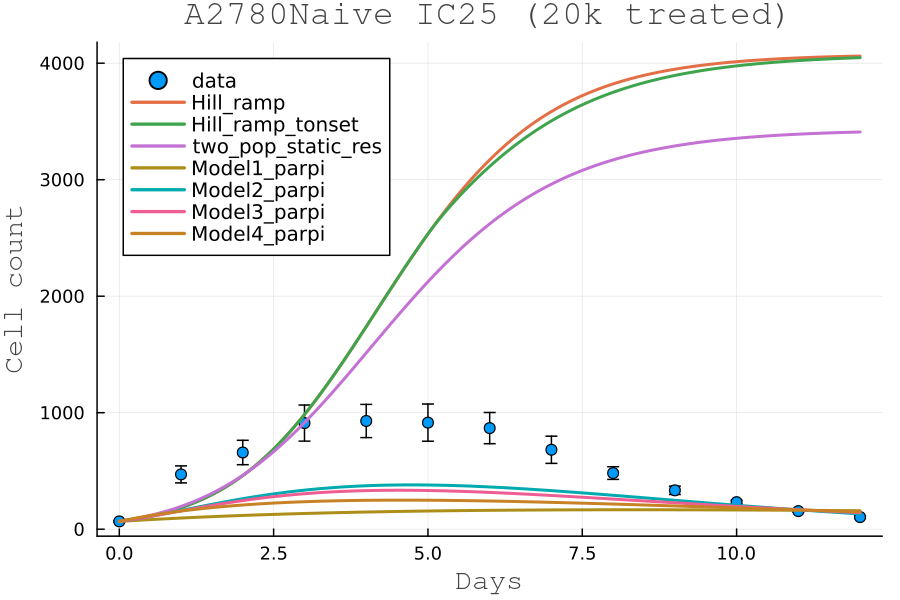

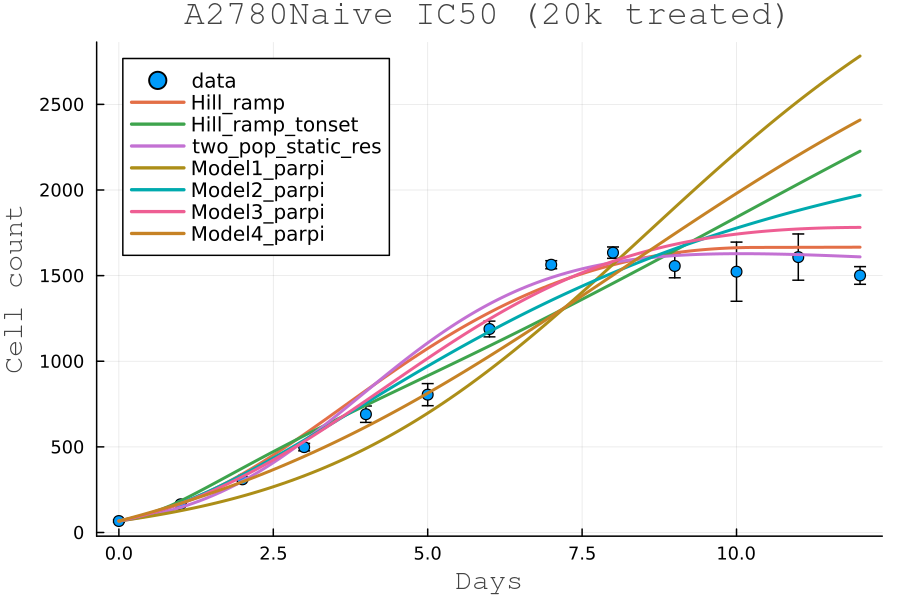

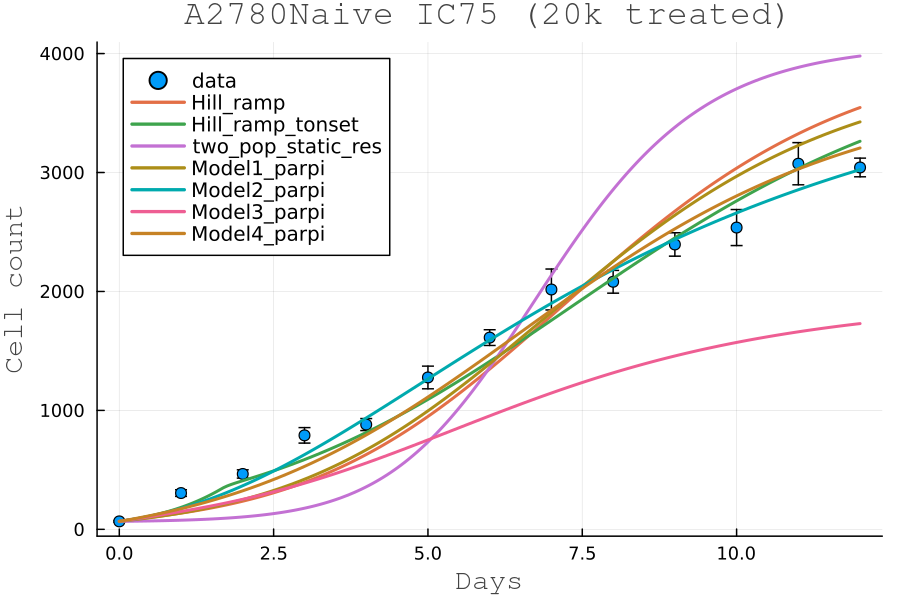

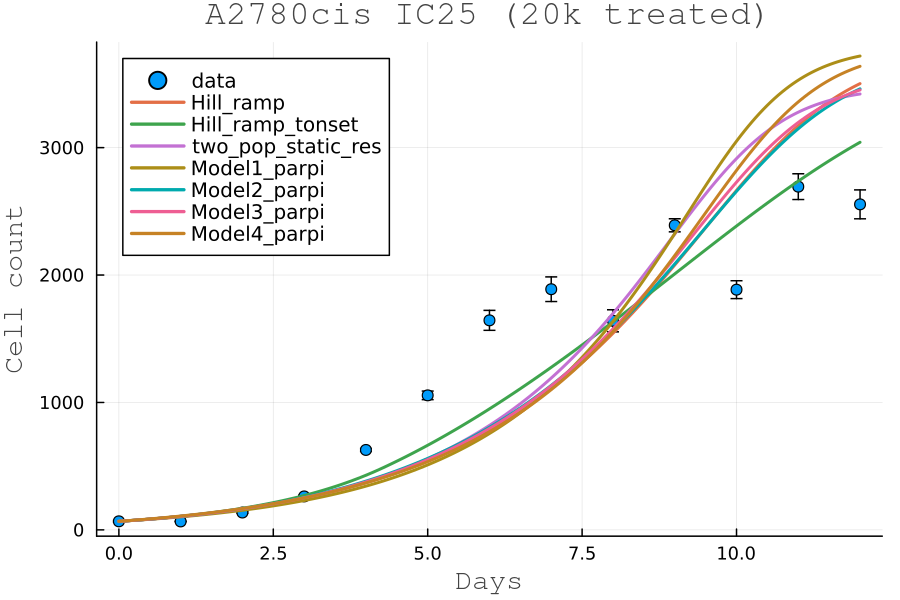

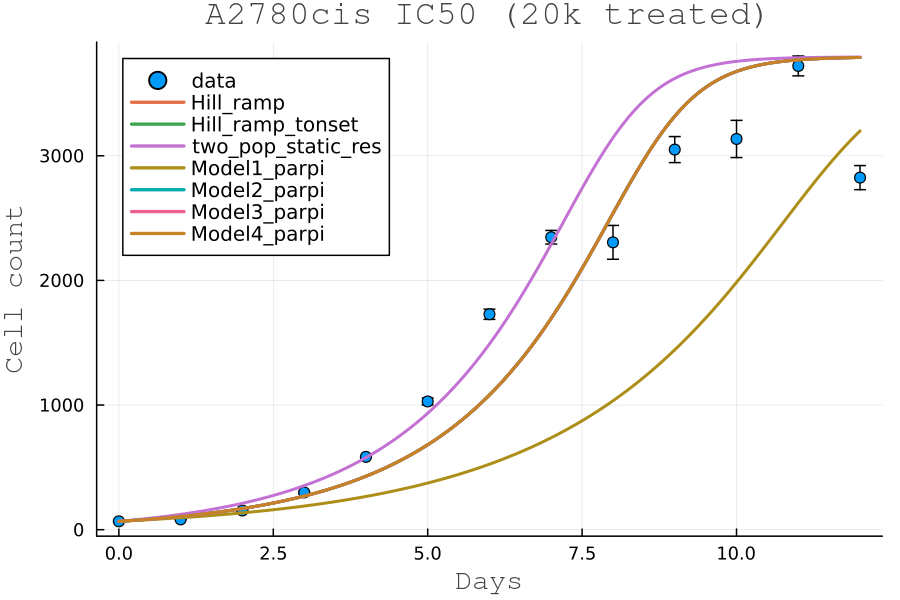

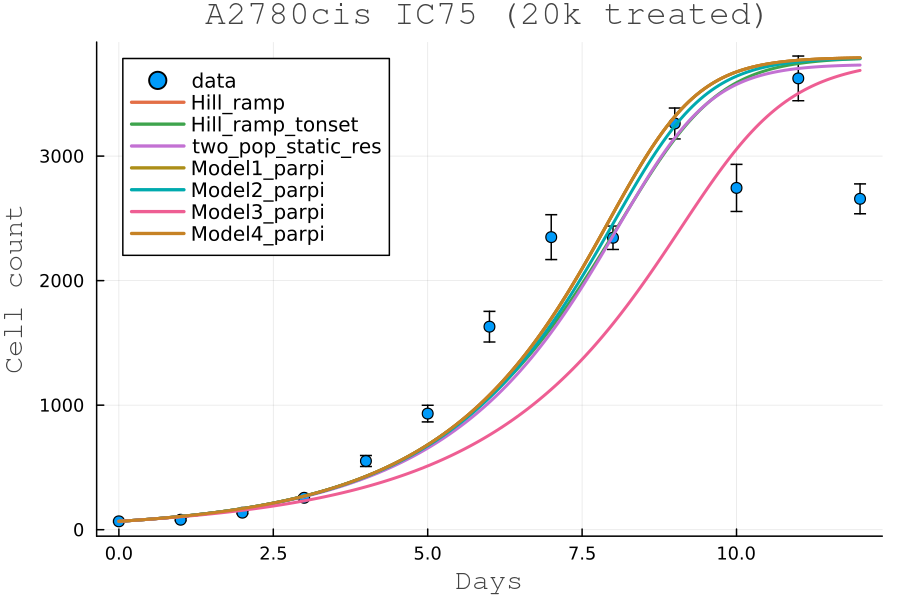

In [16]:
###############################
# MODEL ZOO ACROSS ALL 20k DATA
###############################

using DifferentialEquations
using Optim
using Distributions
using Plots
using DataFrames

# ------------------------------
# 0) Helper: find treated CSV
# ------------------------------

function find_treated_file(dose_dir::AbstractString, cell_line::Symbol)
    name_sub = lowercase(String(cell_line))          # :A2780Naive -> "a2780naive"
    files = filter(f ->
        endswith(f, ".csv") &&
        occursin("day_averages", lowercase(f)) &&
        occursin(name_sub, lowercase(f)),
        readdir(dose_dir; join=true)
    )
    @assert !isempty(files) "No day_averages CSV for $cell_line in $dose_dir"
    return files[1]
end

# ------------------------------
# 1) Struct for models
# ------------------------------

if !@isdefined DoseResponseModel
    struct DoseResponseModel
        name::String
        pnames::Vector{Symbol}         # parameter names
        lower::Vector{Float64}
        upper::Vector{Float64}
        simulate::Function             # (t, p, dose, r,K,v,y0) -> y_pred
    end
end

# ------------------------------
# 2) Two-pop logistic (sens + static res)
# ------------------------------

if !@isdefined solve_treated_two_pop_static
    function solve_treated_two_pop_static(
        t_pts::AbstractVector,
        r::Float64, K::Float64, v::Float64;
        f_s0::Float64,
        E_sens::Float64,
        n::Float64,
        IC50::Float64,
        dose::Float64,
        y0::Float64,
        lambda::Float64,
    )
        t0 = minimum(t_pts)
        tf = maximum(t_pts)

        function f!(du, u, p_, t)
            S, R = u
            N = max(S + R, 1e-12)

            growth_S = r * S * (1 - (N / K)^v)

            # Hill kill on sensitive only, with ramp
            ramp = 1.0 - exp(-max(t, 0.0) / lambda)
            hill = E_sens * (dose^n) / (IC50^n + dose^n)
            kill = ramp * hill

            du[1] = growth_S - kill * S     # sensitive
            du[2] = 0.0                     # resistant/static
        end

        S0 = f_s0 * y0
        R0 = (1.0 - f_s0) * y0
        u0 = [S0, R0]

        prob = ODEProblem(f!, u0, (t0, tf))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        return sol
    end
end

# ------------------------------
# 3) Model definitions
# ------------------------------

# 3.1 Hill-type ramp models (your original style)

model_Hill_ramp = DoseResponseModel(
    "Hill_ramp",
    [:Emax, :n, :lambda, :IC50],
    [0.0, 0.1, 0.01, 1e-3],
    [1.5, 5.0, 10.0, 100.0],
    (t, p, dose, r, K, v, y0) -> begin
        Emax, n, λ, IC50 = p
        sol = solve_treated_theta_logistic_mult_ramped(
            t, r, K, v;
            Emax   = Emax,
            IC50   = IC50,
            n      = n,
            dose   = dose,
            y0     = y0,
            lambda = λ,
            t_onset = 0.0,
        )
        getindex.(sol.u, 1)
    end
)

model_Hill_ramp_tonset = DoseResponseModel(
    "Hill_ramp_tonset",
    [:Emax, :n, :lambda, :IC50, :t_onset],
    [0.0, 0.1, 0.01, 1e-3, 0.0],
    [1.5, 5.0, 10.0, 100.0, 5.0],
    (t, p, dose, r, K, v, y0) -> begin
        Emax, n, λ, IC50, t_onset = p
        sol = solve_treated_theta_logistic_mult_ramped(
            t, r, K, v;
            Emax   = Emax,
            IC50   = IC50,
            n      = n,
            dose   = dose,
            y0     = y0,
            lambda = λ,
            t_onset = t_onset,
        )
        getindex.(sol.u, 1)
    end
)

model_two_pop_static_res = DoseResponseModel(
    "two_pop_static_res",
    [:f_sens0, :E_sens, :n, :IC50, :lambda],
    [0.0, 0.0, 0.5, 1e-3, 0.01],
    [1.0, 2.0, 5.0, 100.0, 10.0],
    (t, p, dose, r, K, v, y0) -> begin
        f_s0, E_sens, n, IC50, λ = p
        sol = solve_treated_two_pop_static(
            t, r, K, v;
            f_s0   = f_s0,
            E_sens = E_sens,
            n      = n,
            IC50   = IC50,
            dose   = dose,
            y0     = y0,
            lambda = λ,
        )
        map(u -> u[1] + u[2], sol.u)
    end
)

# 3.2 PARPi models 1–4 (paper), with α treated as effective parameter
#     since you fit each dose separately

# Model 1
model1_parpi = DoseResponseModel(
    "Model1_parpi",
    [:alpha, :beta, :d],
    [0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, d = p
        αeff = alpha  # effective α(D) for this fixed dose

        function f!(du, u, p_, t)
            P, A = u
            N = P + A
            g = r * (1 - (N / K)^v)
            du[1] = g * (1 - 2*αeff) * P + beta * A
            du[2] = αeff * g * P - beta * A - d * A
        end

        u0 = [y0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# Model 2: n damage compartments collapsed to small fixed n
const M2_NCOMP = 2  # can change to 3 if you want closer to paper

model2_parpi = DoseResponseModel(
    "Model2_parpi",
    [:alpha, :beta, :d],
    [0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, d = p
        αeff = alpha
        n = M2_NCOMP

        function f!(du, u, p_, t)
            # state: P0,...,Pn,A   (length n+2)
            P = u[1:n+1]
            A = u[n+2]
            N = sum(P) + A
            g = r * (1 - (N / K)^v)

            fill!(du, 0.0)

            # P0
            du[1] = g*(1 - 2*αeff)*P[1] + beta * P[2]

            # P_i for i=1..n-1
            for i in 2:n
                Pi_minus = P[i-1]
                Pi       = P[i]
                Pi_plus  = P[i+1]
                du[i] = 2*αeff*g*Pi_minus + g*(1 - 2*αeff)*Pi - beta*Pi + beta*Pi_plus
            end

            # P_n (index n+1)
            Pnm1 = P[n]
            Pn   = P[n+1]
            du[n+1] = 2*αeff*g*Pnm1 + g*(1 - 2*αeff)*Pn - beta*Pn + beta*A

            # A
            du[n+2] = αeff*g*Pn - beta*A - d*A
        end

        u0 = zeros(n+2)
        u0[1] = y0

        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> sum(u[1:n+1]) + u[n+2], sol.u)
    end
)

# Model 3
model3_parpi = DoseResponseModel(
    "Model3_parpi",
    [:alpha, :beta, :gamma, :d],
    [0.0, 0.0, 0.0, 0.0],
    [1.0, 0.5, 4.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, beta, gamma, d = p
        αeff = alpha

        function f!(du, u, p_, t)
            P, Pd, A = u
            N = P + Pd + A
            g = r * (1 - (N / K)^v)

            du[1] = g*(1 - 2*αeff)*P + beta*Pd
            du[2] = 2*αeff*g*P + g*Pd - gamma*Pd - beta*Pd + beta*A
            du[3] = gamma*Pd - beta*A - d*A
        end

        u0 = [y0, 0.0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2] + u[3], sol.u)
    end
)

# Model 4
model4_parpi = DoseResponseModel(
    "Model4_parpi",
    [:alpha, :phi, :d],
    [0.0, 0.0, 0.0],
    [1.0, 2.0, 4.0],
    (t_pts, p, dose, r, K, v, y0) -> begin
        alpha, phi, d = p
        αeff = alpha

        function f!(du, u, p_, t)
            P, A = u
            N = P + A
            g = r * (1 - (N / K)^v)

            du[1] = g*(1 - 2*αeff)*P
            du[2] = (1 + phi)*αeff*g*P - d*A
        end

        u0 = [y0, 0.0]
        prob = ODEProblem(f!, u0, (minimum(t_pts), maximum(t_pts)))
        sol  = solve(prob; saveat=t_pts, reltol=1e-6, abstol=1e-8)
        map(u -> u[1] + u[2], sol.u)
    end
)

# Full model zoo
models = [
    model_Hill_ramp,
    model_Hill_ramp_tonset,
    model_two_pop_static_res,
    model1_parpi,
    model2_parpi,
    model3_parpi,
    model4_parpi,
]

# ------------------------------
# 4) Fitter for one model
# ------------------------------

function fit_one_model(model::DoseResponseModel,
                       t, y, yerr,
                       r, K, v, dose;
                       n_starts::Int = 8)

    t  = collect(Float64.(t))
    y  = collect(Float64.(y))
    ye = collect(Float64.(yerr))
    y0 = y[1]

    n_obs = length(y)
    kpar  = length(model.pnames)

    function loss(p)
        p_clamped = clamp.(p, model.lower, model.upper)
        y_pred = try
            model.simulate(t, p_clamped, dose, r, K, v, y0)
        catch
            return 1e12
        end
        if length(y_pred) != n_obs
            return 1e12
        end
        w   = 1.0 ./ (ye.^2 .+ 1e-12)
        sse = sum(w .* (y_pred .- y).^2)
        return sse
    end

    best_res = nothing
    best_val = Inf

    for s in 1:n_starts
        init = [rand(Uniform(lo, hi)) for (lo, hi) in zip(model.lower, model.upper)]
        res  = Optim.optimize(
            loss, model.lower, model.upper, init,
            Fminbox(NelderMead()),
            Optim.Options(iterations=400, show_trace=false)
        )
        val = Optim.minimum(res)
        if val < best_val
            best_val = val
            best_res = res
        end
    end

    p̂   = Optim.minimizer(best_res)
    sse = best_val
    σ2  = sse / n_obs
    bic = n_obs * log(σ2) + kpar * log(n_obs)
    aic = n_obs * log(σ2) + 2kpar

    return (model = model,
            p̂ = p̂,
            sse = sse,
            bic = bic,
            aic = aic)
end

# ------------------------------
# 5) Plotting for one dataset
# ------------------------------

function plot_model_comparison(x, y, yerr,
                               r, K, v, dose_val,
                               results;
                               title_str::AbstractString = "")
    t_dense = collect(range(minimum(x), maximum(x), length=200))
    y0      = y[1]

    plt = plot()
    plot!(plt, x, y;
          seriestype = :scatter,
          yerror     = yerr,
          label      = "data",
          markersize = 4)

    for res in results
        model = res.model
        p     = res.p̂
        y_pred_dense = try
            model.simulate(t_dense, p, dose_val, r, K, v, y0)
        catch
            continue
        end
        plot!(plt, t_dense, y_pred_dense; label = model.name)
    end

    xlabel!(plt, "Days")
    ylabel!(plt, "Cell count")
    title!(plt, title_str)
    return plt
end

# ------------------------------
# 6) Run across all 20k datasets
# ------------------------------

dose_dirs = Dict(
    "IC25" => IC25_DIR,
    "IC50" => IC50_DIR,
    "IC75" => IC75_DIR,
)

dose_vals = Dict(
    "IC25" => 1.47,
    "IC50" => 1.00,
    "IC75" => 0.62,
)

cell_lines = [:A2780Naive, :A2780cis]

all_results = Dict{Tuple{Symbol,String},Vector{NamedTuple}}()

summary_rows = DataFrame(
    cell_line = String[],
    dose_name = String[],
    model     = String[],
    sse       = Float64[],
    bic       = Float64[],
    aic       = Float64[],
)

for cl in cell_lines
    for dn in ("IC25", "IC50", "IC75")
        dose_dir  = dose_dirs[dn]
        dose_val  = dose_vals[dn]
        data_path = find_treated_file(dose_dir, cl)

        println("\n==============================")
        println("Fitting $cl at $dn (20k treated)")
        println("Dataset: $data_path")

        # load data
        x, y, yerr = load_day_averages_with_day0(data_path)

        # baseline parameters
        r, K, v = rk_params[cl]

        # fit all models
        results = [fit_one_model(m, x, y, yerr, r, K, v, dose_val) for m in models]
        all_results[(cl, dn)] = results

        # fill summary table
        for res in results
            push!(summary_rows, (
                String(cl),
                dn,
                res.model.name,
                res.sse,
                res.bic,
                res.aic,
            ))
        end

        # choose best by BIC
        best = argmin(res -> res.bic, results)
        param_names  = best.model.pnames
        param_values = best.p̂
        params       = (; zip(param_names, param_values)...)

        println("Best model by BIC: ", best.model.name)
        println("Parameters: ", params)
        println("SSE = ", best.sse, ", BIC = ", best.bic, ", AIC = ", best.aic)

        # plot and save comparison
        plt_title = string(cl, " ", dn, " (20k treated)")
        plt = plot_model_comparison(x, y, yerr, r, K, v, dose_val, results;
                                    title_str = plt_title)

        display(plt)  # show in notebook

        out_name = "model_comparison_$(String(cl))_$(dn)_20k.png"
        out_path = joinpath(OUT_DIR, out_name)
        savefig(plt, out_path)
        println("Saved plot to $out_path")
    end
end

println("\n================ BIC/AIC summary ================")
sort!(summary_rows, [:cell_line, :dose_name, :bic])
show(summary_rows, allrows=true, allcols=true)
println()


In [17]:
###############################################
# BIC ANALYSIS: GLOBAL AND PER CELL LINE
###############################################

using DataFrames
using Statistics

@assert @isdefined(summary_rows) "Run the model-fit cell first."

println("Total fits in summary_rows: ", nrow(summary_rows))

# ---------- 1) Global model comparison ----------

global_stats = combine(
    groupby(summary_rows, :model)
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(global_stats, :sum_bic)  # lower is better

println("\n=== Global model ranking by total BIC ===")
show(global_stats, allrows=true, allcols=true)
println()

best_global = global_stats[1, :]
println("\nBest global model by BIC: ", best_global.model)
println("  total BIC = ", best_global.sum_bic,
        ", mean BIC = ", best_global.mean_bic,
        ", datasets = ", best_global.n_datasets)

# ---------- 2) Per-cell-line model comparison ----------

by_cell_model = combine(
    groupby(summary_rows, [:cell_line, :model])
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(by_cell_model, [:cell_line, :sum_bic])

println("\n=== Per cell-line model ranking by total BIC ===")
show(by_cell_model, allrows=true, allcols=true)
println()

for cl in unique(by_cell_model.cell_line)
    sub = filter(row -> row.cell_line == cl, by_cell_model)
    best = sub[1, :]
    println("\nBest model for cell line ", cl, ": ", best.model)
    println("  total BIC = ", best.sum_bic,
            ", mean BIC = ", best.mean_bic,
            ", datasets = ", best.n_datasets)
end


Total fits in summary_rows: 42

=== Global model ranking by total BIC ===
7×4 DataFrame
 Row │ model               mean_bic  sum_bic  n_datasets 
     │ String              Float64   Float64  Int64      
─────┼───────────────────────────────────────────────────
   1 │ Model2_parpi         47.5643  285.386           6
   2 │ Model4_parpi         52.3689  314.213           6
   3 │ Model3_parpi         56.453   338.718           6
   4 │ Model1_parpi         59.9292  359.575           6
   5 │ Hill_ramp            70.2451  421.471           6
   6 │ Hill_ramp_tonset     72.3095  433.857           6
   7 │ two_pop_static_res   73.7436  442.462           6

Best global model by BIC: Model2_parpi
  total BIC = 285.3857746417977, mean BIC = 47.56429577363295, datasets = 6

=== Per cell-line model ranking by total BIC ===
14×5 DataFrame
 Row │ cell_line   model               mean_bic  sum_bic  n_datasets 
     │ String      String              Float64   Float64  Int64      
─────┼────────────

30k IC25 dir: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\30k\IC25\Averages
30k IC50 dir: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\30k\IC50\Averages
30k IC75 dir: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\30k\IC75\Averages
30k output dir: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\30k\Multi_Dose_Analysis
rk_params_30k keys: [:A2780cis, :A2780Naive]

Fitting A2780Naive at IC25 (30k treated)
Dataset: c:\Users\elbak\OneDrive\Desktop\ForgeFit\CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\30k\IC25\Averages\A2780Naive_day_averages.csv
Best 30k model by BIC: Model2_parpi
Parameters: (alpha = 0.7428783203567735, beta = 0.0029220609637020723, d = 0.5540915386765463)
SSE = 843.9155514480601, BIC = 61.94518804221499, AIC = 60.25033996983038
Saved 

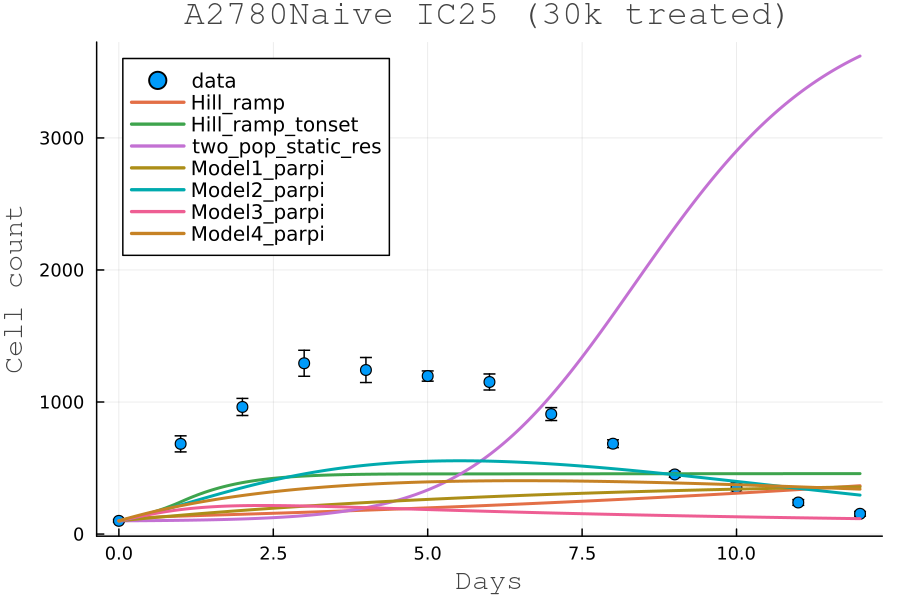

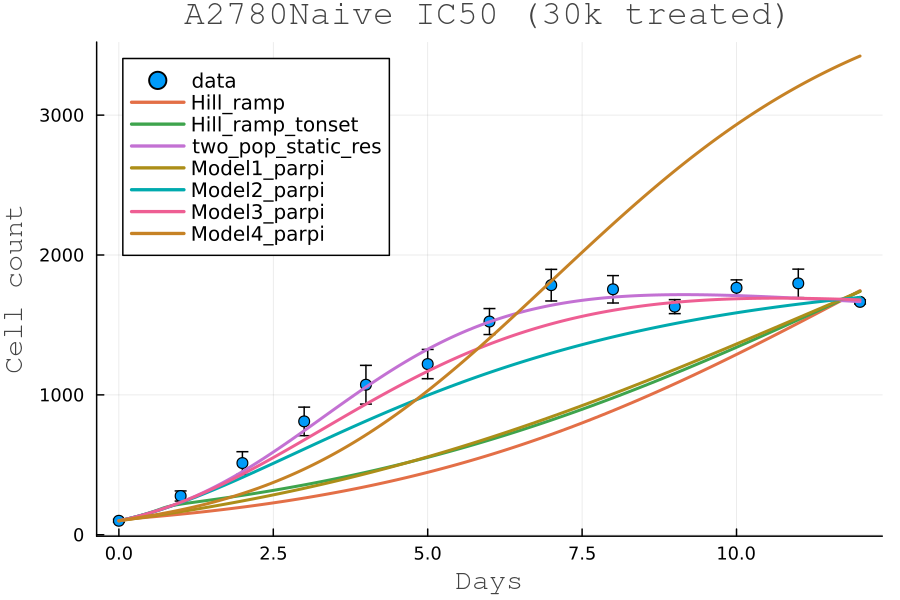

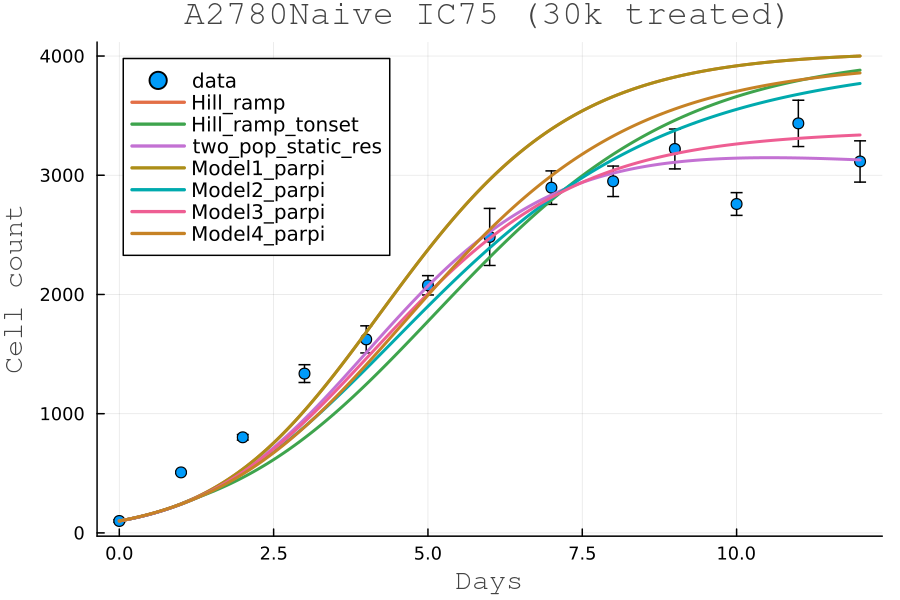

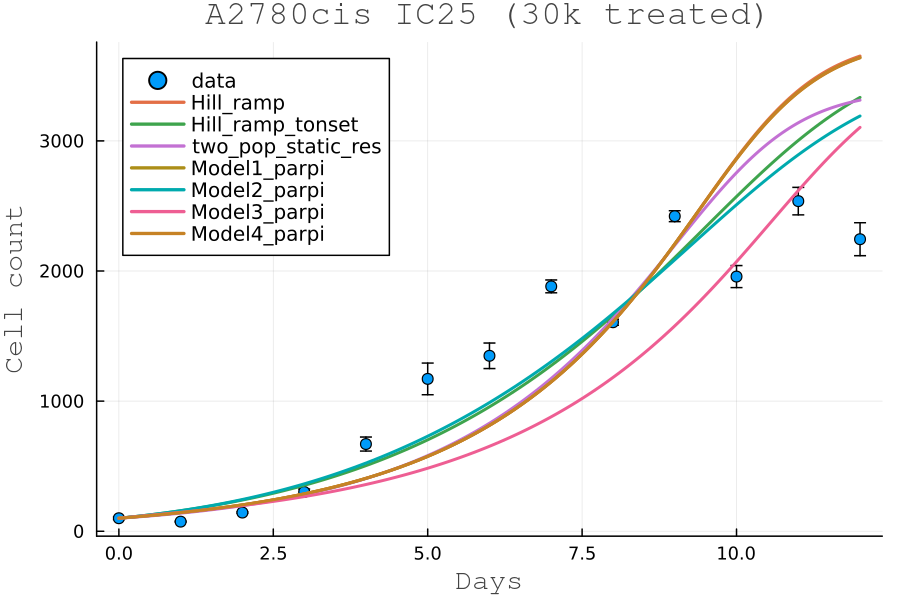

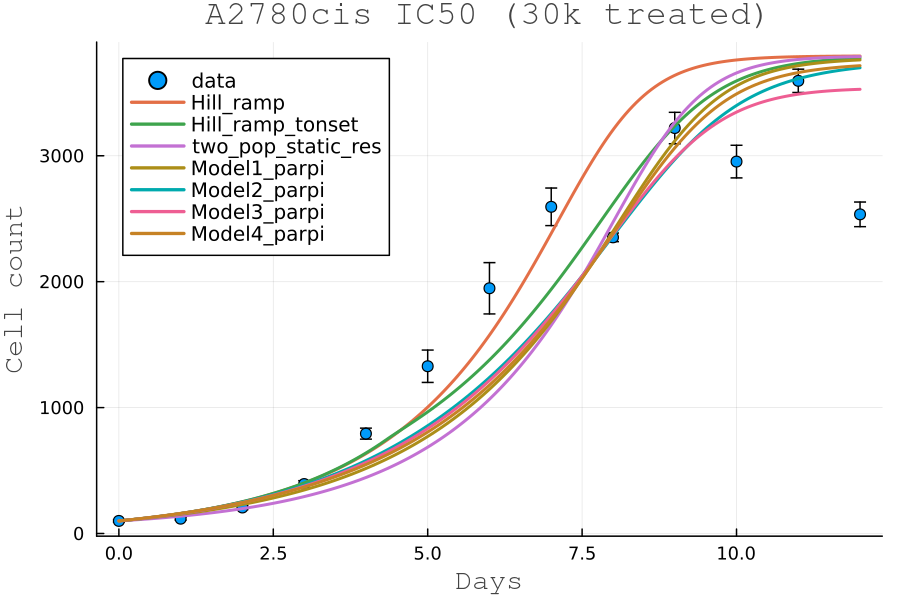

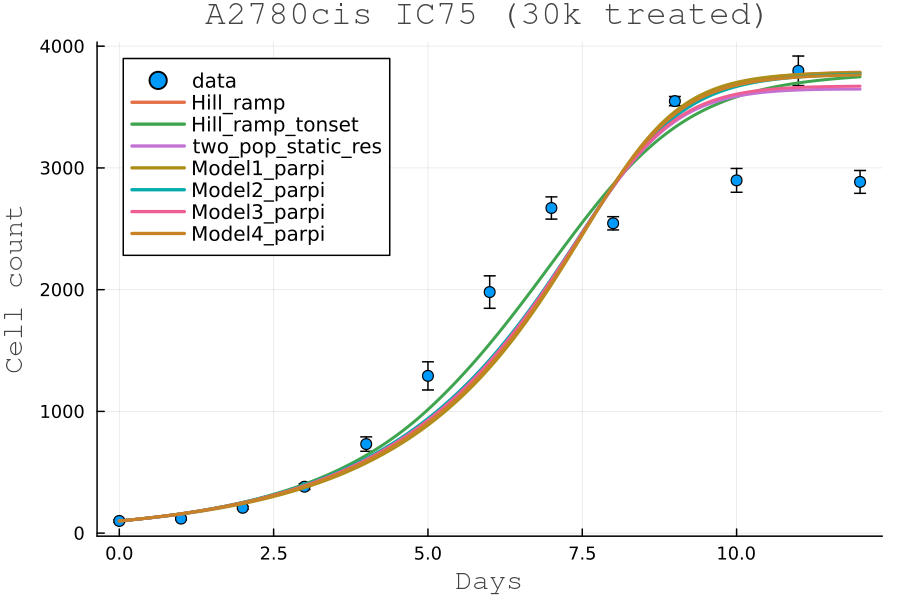

In [18]:
############################################
# Fit model zoo on 30k treated datasets
############################################

using CSV, DataFrames
using Plots

# 1) Directories for 30k data and outputs

IC25_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC25", "Averages")
IC50_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC50", "Averages")
IC75_DIR_30k = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "30k", "IC75", "Averages")

OUT_DIR_30k = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "30k", "Multi_Dose_Analysis")
isdir(OUT_DIR_30k) || mkpath(OUT_DIR_30k)

println("30k IC25 dir: ", IC25_DIR_30k)
println("30k IC50 dir: ", IC50_DIR_30k)
println("30k IC75 dir: ", IC75_DIR_30k)
println("30k output dir: ", OUT_DIR_30k)

# 2) Load baseline logistic parameters for 30k (r, K, v)

rk_df = CSV.read(RK_FILE, DataFrame)

rk_params_30k = Dict{Symbol,Tuple{Float64,Float64,Float64}}()
for row in eachrow(rk_df)
    string(row.Density) == "30k" || continue
    cl_sym = Symbol(row.CellLine)
    rk_params_30k[cl_sym] = (Float64(row.r), Float64(row.K), Float64(row.v))
end

println("rk_params_30k keys: ", collect(keys(rk_params_30k)))

# 3) Loop setup

dose_dirs_30k = Dict(
    "IC25" => IC25_DIR_30k,
    "IC50" => IC50_DIR_30k,
    "IC75" => IC75_DIR_30k,
)

dose_vals = Dict(   # same doses as 20k
    "IC25" => 1.47,
    "IC50" => 1.00,
    "IC75" => 0.62,
)

cell_lines = [:A2780Naive, :A2780cis]

all_results_30k = Dict{Tuple{Symbol,String},Vector{NamedTuple}}()

summary_rows_30k = DataFrame(
    cell_line = String[],
    dose_name = String[],
    model     = String[],
    sse       = Float64[],
    bic       = Float64[],
    aic       = Float64[],
)

# 4) Fit all models on all 30k datasets

for cl in cell_lines
    @assert haskey(rk_params_30k, cl) "No 30k rk_params for $cl"

    for dn in ("IC25", "IC50", "IC75")
        dose_dir  = dose_dirs_30k[dn]
        dose_val  = dose_vals[dn]
        data_path = find_treated_file(dose_dir, cl)

        println("\n==============================")
        println("Fitting $cl at $dn (30k treated)")
        println("Dataset: $data_path")

        # load data; helper already inserts day0=100 for 30k
        x, y, yerr = load_day_averages_with_day0(data_path)

        # baseline parameters for 30k
        r, K, v = rk_params_30k[cl]

        # fit all models from the existing zoo
        results = [fit_one_model(m, x, y, yerr, r, K, v, dose_val) for m in models]
        all_results_30k[(cl, dn)] = results

        # store BIC/AIC summary
        for res in results
            push!(summary_rows_30k, (
                String(cl),
                dn,
                res.model.name,
                res.sse,
                res.bic,
                res.aic,
            ))
        end

        # choose best by BIC
        best = argmin(res -> res.bic, results)
        param_names  = best.model.pnames
        param_values = best.p̂
        params       = (; zip(param_names, param_values)...)

        println("Best 30k model by BIC: ", best.model.name)
        println("Parameters: ", params)
        println("SSE = ", best.sse, ", BIC = ", best.bic, ", AIC = ", best.aic)

        # plot and save comparison
        plt_title = string(cl, " ", dn, " (30k treated)")
        plt = plot_model_comparison(x, y, yerr, r, K, v, dose_val, results;
                                    title_str = plt_title)

        display(plt)

        out_name = "model_comparison_$(String(cl))_$(dn)_30k.png"
        out_path = joinpath(OUT_DIR_30k, out_name)
        savefig(plt, out_path)
        println("Saved 30k plot to $out_path")
    end
end

println("\n=========== 30k BIC/AIC summary (sorted by BIC) ===========")
sort!(summary_rows_30k, [:cell_line, :dose_name, :bic])
show(summary_rows_30k, allrows=true, allcols=true)
println()


In [19]:
###############################################
# BIC ANALYSIS: GLOBAL AND PER CELL LINE
###############################################

using DataFrames
using Statistics

@assert @isdefined(summary_rows_30k) "Run the model-fit cell first."

println("Total fits in summary_rows: ", nrow(summary_rows_30k))

# ---------- 1) Global model comparison ----------

global_stats = combine(
    groupby(summary_rows_30k, :model)
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(global_stats, :sum_bic)  # lower is better

println("\n=== Global model ranking by total BIC ===")
show(global_stats, allrows=true, allcols=true)
println()

best_global = global_stats[1, :]
println("\nBest global model by BIC: ", best_global.model)
println("  total BIC = ", best_global.sum_bic,
        ", mean BIC = ", best_global.mean_bic,
        ", datasets = ", best_global.n_datasets)

# ---------- 2) Per-cell-line model comparison ----------

by_cell_model = combine(
    groupby(summary_rows_30k, [:cell_line, :model])
) do sdf
    (; mean_bic = mean(sdf.bic),
       sum_bic  = sum(sdf.bic),
       n_datasets = nrow(sdf))
end

sort!(by_cell_model, [:cell_line, :sum_bic])

println("\n=== Per cell-line model ranking by total BIC ===")
show(by_cell_model, allrows=true, allcols=true)
println()

for cl in unique(by_cell_model.cell_line)
    sub = filter(row -> row.cell_line == cl, by_cell_model)
    best = sub[1, :]
    println("\nBest model for cell line ", cl, ": ", best.model)
    println("  total BIC = ", best.sum_bic,
            ", mean BIC = ", best.mean_bic,
            ", datasets = ", best.n_datasets)
end


Total fits in summary_rows: 42

=== Global model ranking by total BIC ===
7×4 DataFrame
 Row │ model               mean_bic  sum_bic  n_datasets 
     │ String              Float64   Float64  Int64      
─────┼───────────────────────────────────────────────────
   1 │ Model2_parpi         53.2468  319.481           6
   2 │ Model3_parpi         55.3067  331.84            6
   3 │ Model1_parpi         59.0602  354.361           6
   4 │ two_pop_static_res   63.424   380.544           6
   5 │ Hill_ramp_tonset     64.0658  384.395           6
   6 │ Hill_ramp            64.8667  389.2             6
   7 │ Model4_parpi         65.6821  394.093           6

Best global model by BIC: Model2_parpi
  total BIC = 319.4809778510417, mean BIC = 53.246829641840286, datasets = 6

=== Per cell-line model ranking by total BIC ===
14×5 DataFrame
 Row │ cell_line   model               mean_bic  sum_bic  n_datasets 
     │ String      String              Float64   Float64  Int64      
─────┼───────────